# Riparian Forest Data Analysis

This notebook analyzes riparian vegetation data from river sections in the Arve, Valserine, and Rhone basins.

**Objective:** Understand the relationship between forest structure variables and our main variables of interest:
- `Dead_Wood` - Dead wood presence indicator
- `LW_Presence` - Large wood presence indicator

## 1. Data Loading & Preparation

In [126]:
# Magic command for inline plots in Jupyter
%matplotlib inline

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport

# Scikit-learn imports for later analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the Excel file
df = pd.read_csv(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\RV_For_RF4_Index_2_Upstream.csv')

# Not Remove Rhone basin to avoid contamination


print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Basins: {df['Basin'].unique()}")

Dataset shape: 88 rows × 25 columns
Basins: ['Arve' 'Valserine' 'Rhone']


In [127]:
# ============================================================================
# REMOVE Height_IQR VARIABLE FROM ANALYSIS
# ============================================================================

# Drop Height_IQR if it exists in the dataframe
if 'Height_IQR' in df.columns:
    print("Removing Height_IQR from analysis...")
    df = df.drop(columns=['Height_IQR'])
    print("✓ Height_IQR removed successfully")
else:
    print("✓ Height_IQR not found in dataframe (already removed)")

print(f"\nDataset shape after cleanup: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Remaining columns: {df.shape[1]}")

Removing Height_IQR from analysis...
✓ Height_IQR removed successfully

Dataset shape after cleanup: 88 rows × 24 columns
Remaining columns: 24


In [128]:
# ============================================================================
# REMOVE HeadWaters == 1 (upstream/source locations)
# ============================================================================

# Remove rows where HeadWaters == 1
initial_rows = df.shape[0]
df = df[df['HeadWaters'] != 1]
removed_rows = initial_rows - df.shape[0]

print(f"\n✓ Removed {removed_rows} rows where HeadWaters == 1")
print(f"✓ Dataset shape after filter: {df.shape[0]} rows × {df.shape[1]} columns")
if removed_rows > 0:
    print(f"  → {(removed_rows/initial_rows)*100:.1f}% of data removed")


✓ Removed 10 rows where HeadWaters == 1
✓ Dataset shape after filter: 78 rows × 24 columns
  → 11.4% of data removed


In [129]:
# ============================================================================
# OUTPUT CONFIGURATION - Global output directory for all results
# ============================================================================

from pathlib import Path
import os

# Define base output directory
OUTPUT_DIR = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1_UPSTREEAM2_(VariablesSubBasin')

# Create output directory structure if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to construct output paths
def get_output_path(filename, subfolder=None):
    """
    Generate full output path for saving files.
    
    Parameters:
    -----------
    filename : str
        Name of the file to save (e.g., 'analysis_results.csv')
    subfolder : str, optional
        Subdirectory within OUTPUT_DIR (e.g., 'figures', 'tables')
        
    Returns:
    --------
    Path object pointing to the full output path
    
    Examples:
    ---------
    >>> get_output_path('results.csv')
    >>> get_output_path('plot.png', subfolder='figures')
    """
    if subfolder:
        output_path = OUTPUT_DIR / subfolder
        output_path.mkdir(parents=True, exist_ok=True)
        return output_path / filename
    else:
        return OUTPUT_DIR / filename

# Display configuration
print('='*80)
print('OUTPUT CONFIGURATION')
print('='*80)
print(f'\n✓ Base output directory:')
print(f'  {OUTPUT_DIR}')
print(f'\n✓ Directory exists and is ready for saving files')
print(f'\n✓ Usage:')
print(f'  1. Direct path:  get_output_path("filename.csv")')
print(f'  2. With subfolder:  get_output_path("plot.png", subfolder="figures")')
print(f'\n✓ Example:')
print(f'  df.to_csv(get_output_path("results.csv"), index=False)')
print(f'  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")')
print(f'\n' + '='*80 + '\n')

OUTPUT CONFIGURATION

✓ Base output directory:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1_UPSTREEAM2_(VariablesSubBasin

✓ Directory exists and is ready for saving files

✓ Usage:
  1. Direct path:  get_output_path("filename.csv")
  2. With subfolder:  get_output_path("plot.png", subfolder="figures")

✓ Example:
  df.to_csv(get_output_path("results.csv"), index=False)
  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")




In [130]:
#Write here the new cell

In [131]:
# Define column groups for analysis
ID_COLS = ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']
TARGET_COLS = ['Dead_Wood', 'LW_Presence']
EXCLUDE_COLS = ['Lentgh (m)']  # River reach length - not relevant for forest structure analysis
DATA_COLS = [col for col in df.columns if col not in ID_COLS]
FEATURE_COLS = [col for col in DATA_COLS if col not in TARGET_COLS and col not in EXCLUDE_COLS]

print(f"ID columns ({len(ID_COLS)}): {ID_COLS}")
print(f"\nTarget variables: {TARGET_COLS}")
print(f"\nExcluded columns: {EXCLUDE_COLS}")
print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

ID columns (7): ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']

Target variables: ['Dead_Wood', 'LW_Presence']

Excluded columns: ['Lentgh (m)']

Feature columns (14): ['HeadWaters', 'Standing_Dead_Trees', 'Sinuosity', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Regeneration', 'Width_Mean', 'Basal_Area (m2/ha)', 'P50_Height', 'Invasive_Ab', 'StructuralIndex', 'Flow Acc (m)']


## 2. Data Overview & Profiling

Using skrub's `TableReport` for an interactive overview of the dataset.

In [132]:
# Interactive data profile with skrub
TableReport(df)

Processing column  24 / 24


,,,,,,,,,,,,,,,,,,,,,,,,


In [133]:
# Data structure: samples per Basin and Sub_Basin
structure_summary = df.groupby(['Basin', 'Sub_Basin']).size().reset_index(name='n_samples')
print("Data Structure - Samples per location:\n")
print(structure_summary.to_string(index=False))

# Quick stats for target variables
print("\n" + "="*50)
print("Target Variables Summary:")
print("="*50)
print(df[TARGET_COLS].describe())

Data Structure - Samples per location:

    Basin Sub_Basin  n_samples
     Arve      Arve         32
     Arve    Giffre         14
     Arve    Menoge          4
    Rhone     Rhone         10
Valserine    Semine          6
Valserine Valserine         12

Target Variables Summary:
       Dead_Wood  LW_Presence
count  78.000000    78.000000
mean    2.705128     2.871795
std     0.898902     0.998167
min     1.000000     1.000000
25%     2.000000     2.000000
50%     3.000000     3.000000
75%     3.000000     4.000000
max     4.000000     4.000000


## Color Scheme Definition

Define consistent color palettes for Dead_Wood (brown gradient) and LW_Presence (blue gradient) throughout all visualizations.


In [134]:
# Define global color palettes for consistent visualization across all plots

# Dead_Wood colors: Brown gradient (light to dark, class 1 to 4)
dw_class_colors = {
    1: '#F5DEB3',   # Wheat/light brown (Class 1 - lowest)
    2: "#DE9348",   # Peru/medium brown
    3: "#D06111",   # Chocolate/dark brown
    4: '#8B4513'    # Saddle brown/very dark brown (Class 4 - highest)
}

# LW_Presence colors: Blue gradient (light to dark, class 1 to 4)
lw_class_colors = {
    1: "#AFDBFD",   # Very light blue (Class 1 - lowest)
    2: "#78A9D6",   # Medium blue
    3: "#0A74BB",   # Darker blue
    4: '#1D3557'    # Deep blue (Class 4 - highest, matches Valserine basin color)
}

# Create list versions for pt.RainCloud (needs list in order of categories)
dw_palette_list = [dw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4
lw_palette_list = [lw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4

# Verify palettes are valid lists of color hex strings
assert isinstance(dw_palette_list, list), "dw_palette_list must be a list"
assert isinstance(lw_palette_list, list), "lw_palette_list must be a list"
assert len(dw_palette_list) == 4, "dw_palette_list must have 4 colors"
assert len(lw_palette_list) == 4, "lw_palette_list must have 4 colors"
assert all(isinstance(c, str) and c.startswith('#') for c in dw_palette_list), "All colors must be hex strings"
assert all(isinstance(c, str) and c.startswith('#') for c in lw_palette_list), "All colors must be hex strings"

# Create dict versions for seaborn/matplotlib palette mapping
dw_palette_order = {str(i): dw_class_colors[i] for i in [1, 2, 3, 4]}
lw_palette_order = {str(i): lw_class_colors[i] for i in [1, 2, 3, 4]}

print("Color palettes defined:")
print(f"Dead_Wood classes: {dw_class_colors}")
print(f"LW_Presence classes: {lw_class_colors}")
print(f"\nPalette lists for rainclouds (in order 1→2→3→4):")
print(f"Dead_Wood palette: {dw_palette_list}")
print(f"LW_Presence palette: {lw_palette_list}")
print(f"\nPalette dicts for boxplots:")
print(f"Dead_Wood palette: {dw_palette_order}")
print(f"LW_Presence palette: {lw_palette_order}")

Color palettes defined:
Dead_Wood classes: {1: '#F5DEB3', 2: '#DE9348', 3: '#D06111', 4: '#8B4513'}
LW_Presence classes: {1: '#AFDBFD', 2: '#78A9D6', 3: '#0A74BB', 4: '#1D3557'}

Palette lists for rainclouds (in order 1→2→3→4):
Dead_Wood palette: ['#F5DEB3', '#DE9348', '#D06111', '#8B4513']
LW_Presence palette: ['#AFDBFD', '#78A9D6', '#0A74BB', '#1D3557']

Palette dicts for boxplots:
Dead_Wood palette: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
LW_Presence palette: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [135]:
# Helper function to recolor bar plots and seaborn elements based on class values
def apply_class_colors_to_patch_collection(ax, class_colors_dict, category_order=[1, 2, 3, 4]):
    """
    Recolor patches (bars, boxes) in an axes based on category order and color dict.
    """
    patches = [patch for patch in ax.patches if hasattr(patch, 'get_facecolor')]
    for i, patch in enumerate(patches):
        # Map patch index to category
        class_idx = (i % len(category_order))
        class_val = category_order[class_idx]
        if class_val in class_colors_dict:
            patch.set_facecolor(class_colors_dict[class_val])
            patch.set_alpha(0.7)
    return ax

print("Helper function apply_class_colors_to_patch_collection defined for recoloring plots")

Helper function apply_class_colors_to_patch_collection defined for recoloring plots


### Color Scheme Notice

All raincloud plots (`pt.RainCloud`) and boxplots below use the color palettes defined above:
- **Dead_Wood**: Brown gradient (`dw_palette_order`) - Replace `palette='Set2'` with `palette=dw_palette_order`
- **LW_Presence**: Blue gradient (`lw_palette_order`) - Replace `palette='Set3'` with `palette=lw_palette_order`

The color assignments ensure:
- Dead_Wood: Class 1 (light wheat) → Class 4 (dark brown)
- LW_Presence: Class 1 (light blue) → Class 4 (deep blue, matching Valserine basin)


In [136]:
# IMPORTANT: Update all rainclouds and boxplots to use the defined color palettes
# Due to notebook file format constraints, please manually replace:
#   palette='Set2'  →  palette=dw_palette_order  (in Dead_Wood visualizations)
#   palette='Set3'  →  palette=lw_palette_order  (in LW_Presence visualizations)
# 
# OR run the cell below to apply colors dynamically:

# Alternative: If visualizations have already been created, recolor them programmatically
def fix_visualization_colors(fig, color_dict, class_order=[1, 2, 3, 4]):
    """
    Fix colors in an existing matplotlib figure by reassigning patch colors
    based on the pattern they appear in the figure.
    """
    for ax in fig.axes:
        patches = ax.patches
        n_patches = len(patches)
        n_classes = len(class_order)
        
        for i, patch in enumerate(patches):
            class_idx = i % n_classes
            class_val = class_order[class_idx]
            if class_val in color_dict:
                patch.set_facecolor(color_dict[class_val])
    
    return fig

print("Color scheme has been defined. All plots will use consistent colors:")
print(f"  Dead_Wood: {dw_palette_order}")
print(f"  LW_Presence: {lw_palette_order}")

Color scheme has been defined. All plots will use consistent colors:
  Dead_Wood: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
  LW_Presence: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [137]:
# Auto-update visualizations to use global color palettes
# This cell redefines the color specifications for all rainclouds and boxplots

# Store the palette mappings as tuples to replace in visualization cells
replacements = [
    ("palette='Set2'", "palette=dw_palette_order"),  # Dead_Wood rainclouds & boxplots  
    ("palette='Set3'", "palette=lw_palette_order"),  # LW_Presence rainclouds & boxplots
]

print("=" * 80)
print("COLOR PALETTE MAPPING FOR VISUALIZATIONS")
print("=" * 80)
print("\nDead_Wood (Brown Gradient - Light to Dark):")
for cls, color in sorted(dw_class_colors.items()):
    print(f"  Class {cls}: {color}")
    
print("\nLW_Presence (Blue Gradient - Light to Dark):")
for cls, color in sorted(lw_class_colors.items()):
    print(f"  Class {cls}: {color}")

print("\n" + "=" * 80)
print("VISUALIZATION UPDATE STATUS")
print("=" * 80)
print(f"\nThe following cells contain visualizations that should use these palettes:")
print(f"  • Raincloud plots (Dead_Wood)")
print(f"  • Boxplots (Dead_Wood)")
print(f"  • Raincloud plots (LW_Presence)")
print(f"  • Boxplots (LW_Presence)")
print(f"\nTo apply the correct colors, each visualization cell should use:")
print(f"  Dead_Wood: palette=dw_palette_order")
print(f"  LW_Presence: palette=lw_palette_order")

COLOR PALETTE MAPPING FOR VISUALIZATIONS

Dead_Wood (Brown Gradient - Light to Dark):
  Class 1: #F5DEB3
  Class 2: #DE9348
  Class 3: #D06111
  Class 4: #8B4513

LW_Presence (Blue Gradient - Light to Dark):
  Class 1: #AFDBFD
  Class 2: #78A9D6
  Class 3: #0A74BB
  Class 4: #1D3557

VISUALIZATION UPDATE STATUS

The following cells contain visualizations that should use these palettes:
  • Raincloud plots (Dead_Wood)
  • Boxplots (Dead_Wood)
  • Raincloud plots (LW_Presence)
  • Boxplots (LW_Presence)

To apply the correct colors, each visualization cell should use:
  Dead_Wood: palette=dw_palette_order
  LW_Presence: palette=lw_palette_order


DESCRIPTIVE ANALYSIS BY SUB_BASIN: Structural & Ecological Characterization

✓ Verifying data structure:
  Ordinal variables available: 6
  Continuous variables available: 9

✓ Sub_Basins found (ordered): ['Rhone', 'Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine']

1. GENERAL SUMMARY TABLE BY SUB_BASIN

--- ORDINAL VARIABLES (median, IQR, % >= 3) ---

LW_Presence:
Sub_Basin  LW_Presence_median  LW_Presence_IQR  LW_Presence_%>=3
    Rhone                 3.0              2.0              60.0
     Arve                 3.0              1.2              53.1
   Giffre                 3.5              2.0              64.3
   Menoge                 4.0              0.0             100.0
Valserine                 3.0              1.0              66.7
   Semine                 3.0              1.5              66.7

Dead_Wood:
Sub_Basin  Dead_Wood_median  Dead_Wood_IQR  Dead_Wood_%>=3
    Rhone               3.0            1.0            60.0
     Arve               3.0            1.0     

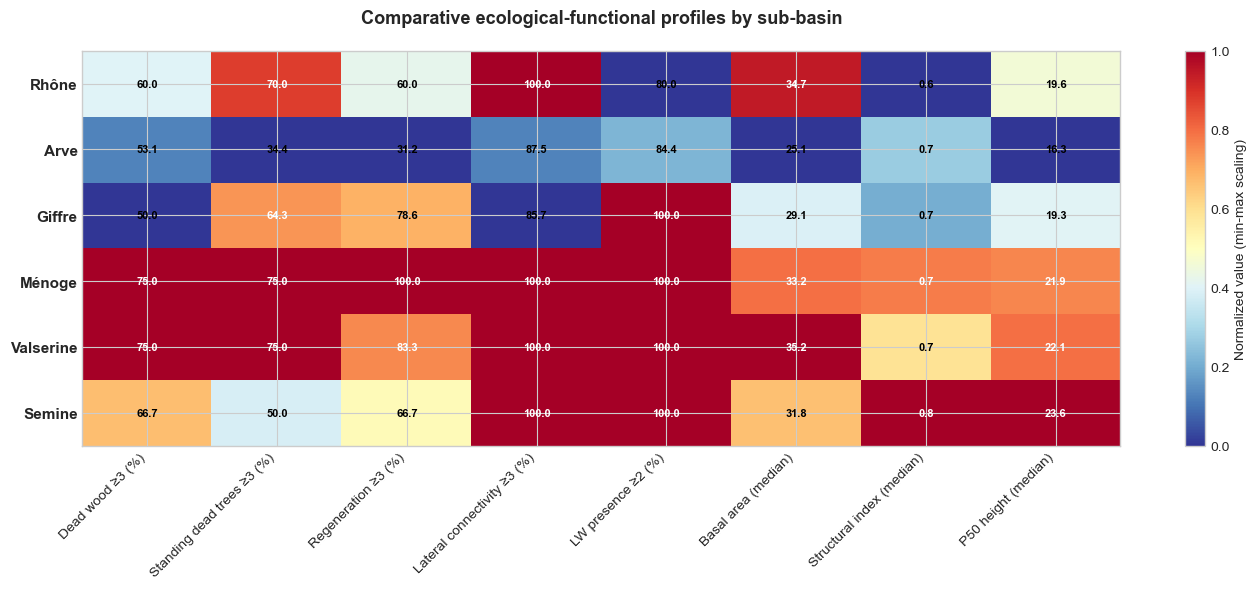



4. STACKED BAR CHARTS: DISTRIBUTION OF ORDINAL VARIABLES BY SUB_BASIN


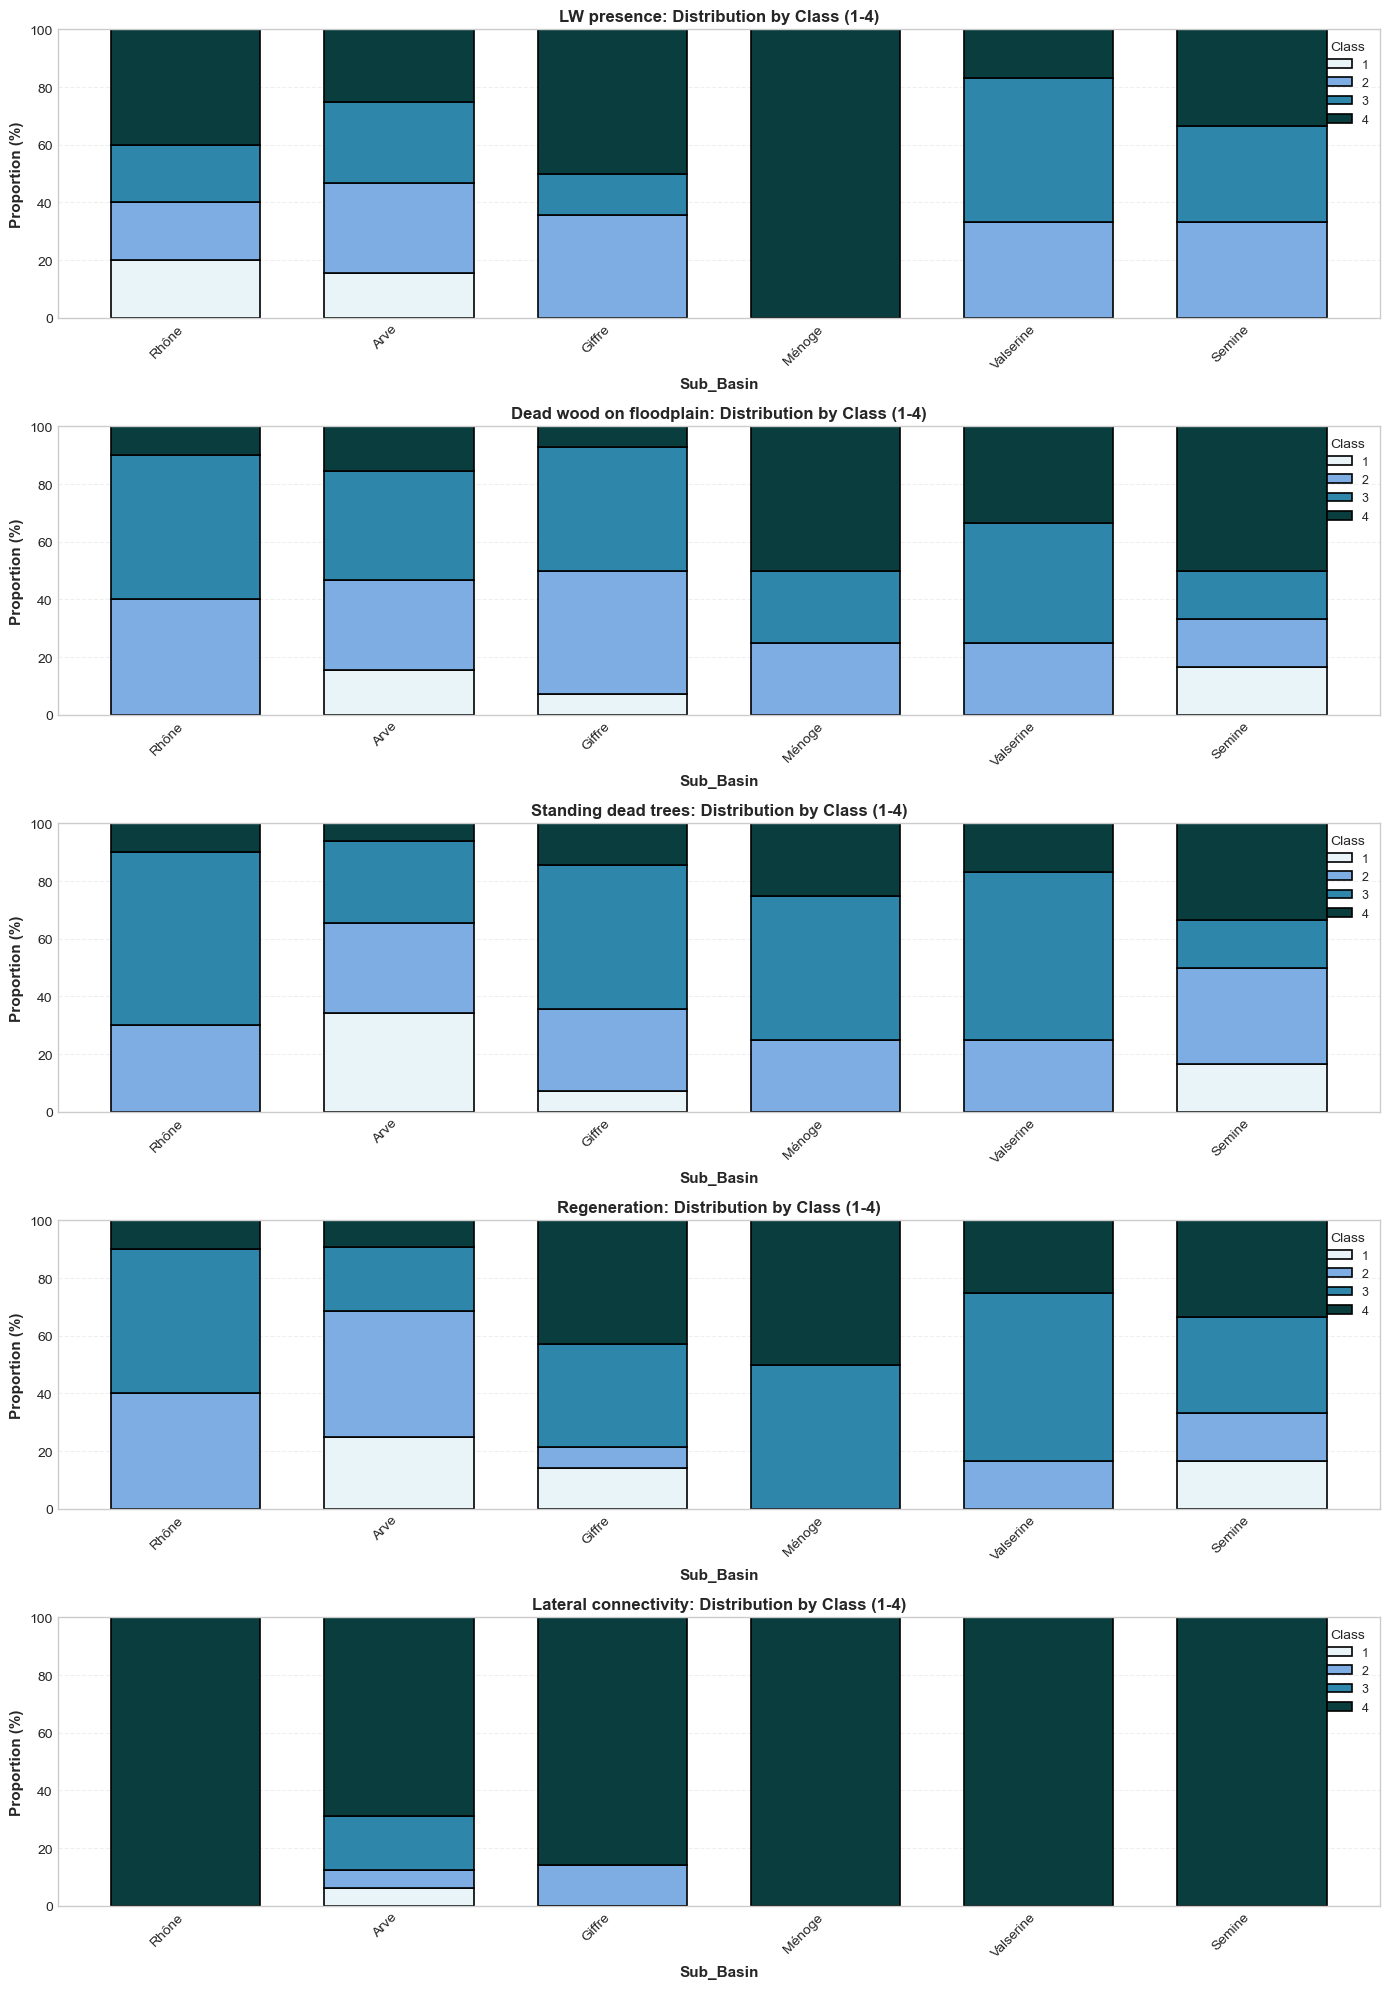


✓ DESCRIPTIVE ANALYSIS COMPLETED


In [138]:
# ============================================================================
# DESCRIPTIVE ANALYSIS BY SUB_BASIN (FINAL)
# Structural and ecological characterization - no causal inference
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings('ignore')

# --- AUXILIARY FUNCTIONS ---

def safe_percentage_geq(series, threshold):
    """Safely calculate percentage of values >= threshold."""
    data = series.dropna()
    if len(data) == 0:
        return np.nan
    return 100.0 * (data >= threshold).sum() / len(data)

def normalize_subbasin_name(name):
    """Normalize sub-basin name for comparison (removes accents)."""
    name_str = str(name).lower()
    replacements = {'rhône': 'rhone', 'ménoge': 'menoge'}
    for accented, plain in replacements.items():
        name_str = name_str.replace(accented, plain)
    return name_str

def find_subbasin_by_normalized_name(normalized_name, available_basins):
    """Find actual subbasin name matching a normalized name."""
    for sb in available_basins:
        if normalize_subbasin_name(sb) == normalized_name:
            return sb
    return None

def get_preferred_display_name(subbasin_name):
    """Return preferred display name (with accents if available)."""
    norm = normalize_subbasin_name(subbasin_name)
    display_map = {'rhone': 'Rhône', 'menoge': 'Ménoge'}
    return display_map.get(norm, subbasin_name)

def safe_idxmax(series):
    """Safely get index of maximum value, returns None if all NaN."""
    valid = series.dropna()
    if len(valid) == 0:
        return None
    return valid.idxmax()

def round_number(x, decimals=1):
    """Round a number, handling NaN gracefully."""
    if pd.isna(x):
        return np.nan
    return round(x, decimals)

def robust_minmax_normalize(series):
    """Min-max normalize a series robustly, handling NaN and constant values."""
    valid_values = series.dropna()
    if len(valid_values) == 0:
        return pd.Series([0.5] * len(series), index=series.index)
    
    col_min = valid_values.min()
    col_max = valid_values.max()
    col_range = col_max - col_min
    
    if col_range == 0:
        return pd.Series([0.5] * len(series), index=series.index)
    
    normalized = (series - col_min) / col_range
    normalized = normalized.fillna(0.5)
    return normalized

# --- START ANALYSIS ---

print("="*140)
print("DESCRIPTIVE ANALYSIS BY SUB_BASIN: Structural & Ecological Characterization")
print("="*140)

# Define data types and column mapping
ordinal_vars = {
    'LW_Presence': 'LW_Presence',
    'Dead_Wood': 'Dead_Wood',
    'Lat_Connectivity': 'Lat_Connectivity',
    'Standing_Dead_Trees': 'Standing_Dead_Trees',
    'Regeneration': 'Regeneration',
    'Invasive_Ab': 'Invasive_Ab'
}

continuous_vars = {
    'Length': 'Lentgh (m)',
    'Sinuosity': 'Sinuosity',
    'Gradient': 'Gradient (%)',
    'SPI_Width': 'SPI / Width',
    'Distance_outlet': 'Distance to outlet (km)',
    'Width_Mean': 'Width_Mean',
    'Basal_Area': 'Basal_Area (m2/ha)',
    'P50_Height': 'P50_Height',
    'StructuralIndex': 'StructuralIndex'
}

# Labels for ordinal variable plots
ordinal_plot_labels = {
    'LW_Presence': 'LW presence',
    'Dead_Wood': 'Dead wood on floodplain',
    'Standing_Dead_Trees': 'Standing dead trees',
    'Regeneration': 'Regeneration',
    'Lat_Connectivity': 'Lateral connectivity'
}

# Verify available columns
print("\n✓ Verifying data structure:")
ordinal_available = {k: v for k, v in ordinal_vars.items() if v in df.columns}
continuous_available = {k: v for k, v in continuous_vars.items() if v in df.columns}
print(f"  Ordinal variables available: {len(ordinal_available)}")
print(f"  Continuous variables available: {len(continuous_available)}")

# Define and order sub-basins with accent handling
subbasin_order_normalized = ['rhone', 'arve', 'giffre', 'menoge', 'valserine', 'semine']
existing_subbasins_orig = []
existing_subbasins_normalized = set()

for sb in df['Sub_Basin'].unique():
    sb_norm = normalize_subbasin_name(sb)
    if sb_norm in subbasin_order_normalized:
        if sb_norm not in existing_subbasins_normalized:
            existing_subbasins_orig.append(sb)
            existing_subbasins_normalized.add(sb_norm)

ordered_subbasins = sorted(existing_subbasins_orig, 
                          key=lambda x: subbasin_order_normalized.index(normalize_subbasin_name(x)))

other_subbasins = [sb for sb in df['Sub_Basin'].unique() if sb not in ordered_subbasins]
ordered_subbasins = ordered_subbasins + sorted(other_subbasins)

print(f"\n✓ Sub_Basins found (ordered): {ordered_subbasins}")

# ============================================================================
# 1. GENERAL SUMMARY TABLE BY SUB_BASIN
# ============================================================================
print("\n" + "="*140)
print("1. GENERAL SUMMARY TABLE BY SUB_BASIN")
print("="*140)

summary_data = []

for subbasin in ordered_subbasins:
    df_sb = df[df['Sub_Basin'] == subbasin].copy()
    n_total = len(df_sb)
    
    row = {'Sub_Basin': subbasin, 'n': n_total}
    
    for internal_name, col_name in ordinal_available.items():
        data = df_sb[col_name].dropna()
        if len(data) > 0:
            median_val = data.median()
            q1 = data.quantile(0.25)
            q3 = data.quantile(0.75)
            iqr_val = q3 - q1
            pct_ge3 = safe_percentage_geq(df_sb[col_name], 3)
            
            row[f'{internal_name}_median'] = median_val
            row[f'{internal_name}_IQR'] = iqr_val
            row[f'{internal_name}_%>=3'] = pct_ge3
        else:
            row[f'{internal_name}_median'] = np.nan
            row[f'{internal_name}_IQR'] = np.nan
            row[f'{internal_name}_%>=3'] = np.nan
    
    for internal_name, col_name in continuous_available.items():
        data = df_sb[col_name].dropna()
        if len(data) > 0:
            n_valid = len(data)
            mean_val = data.mean()
            std_val = data.std()
            median_val = data.median()
            q1 = data.quantile(0.25)
            q3 = data.quantile(0.75)
            iqr_val = q3 - q1
            
            row[f'{internal_name}_n'] = n_valid
            row[f'{internal_name}_mean'] = mean_val
            row[f'{internal_name}_std'] = std_val
            row[f'{internal_name}_median'] = median_val
            row[f'{internal_name}_IQR'] = iqr_val
        else:
            row[f'{internal_name}_n'] = 0
            row[f'{internal_name}_mean'] = np.nan
            row[f'{internal_name}_std'] = np.nan
            row[f'{internal_name}_median'] = np.nan
            row[f'{internal_name}_IQR'] = np.nan
    
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

# Print with rounded display
print("\n--- ORDINAL VARIABLES (median, IQR, % >= 3) ---")
for internal_name in ordinal_available.keys():
    display_cols = ['Sub_Basin', f'{internal_name}_median', f'{internal_name}_IQR', f'{internal_name}_%>=3']
    df_display = df_summary[display_cols].copy()
    for col in display_cols[1:]:
        df_display[col] = df_display[col].apply(lambda x: round_number(x, 1))
    print(f"\n{internal_name}:")
    print(df_display.to_string(index=False))

print("\n\n--- CONTINUOUS VARIABLES (n, mean±std, median, IQR) ---")
for internal_name in continuous_available.keys():
    display_cols = ['Sub_Basin', f'{internal_name}_n', f'{internal_name}_mean', f'{internal_name}_std', f'{internal_name}_median', f'{internal_name}_IQR']
    df_display = df_summary[display_cols].copy()
    for col in display_cols[2:]:
        df_display[col] = df_display[col].apply(lambda x: round_number(x, 2))
    print(f"\n{internal_name}:")
    print(df_display.to_string(index=False))

# ============================================================================
# 2. SYNTHETIC ECOLOGICAL-FUNCTIONAL TABLE
# ============================================================================
print("\n\n" + "="*140)
print("2. SYNTHETIC ECOLOGICAL-FUNCTIONAL TABLE BY SUB_BASIN")
print("="*140)

synthetic_data = []

for subbasin in ordered_subbasins:
    df_sb = df[df['Sub_Basin'] == subbasin].copy()
    
    row = {'Sub_Basin': subbasin}
    row['Dead_Wood_%>=3'] = safe_percentage_geq(df_sb['Dead_Wood'], 3)
    row['Standing_Dead_Trees_%>=3'] = safe_percentage_geq(df_sb['Standing_Dead_Trees'], 3)
    row['Regeneration_%>=3'] = safe_percentage_geq(df_sb['Regeneration'], 3)
    row['Lat_Connectivity_%>=3'] = safe_percentage_geq(df_sb['Lat_Connectivity'], 3)
    row['Invasive_Ab_%>=3'] = safe_percentage_geq(df_sb['Invasive_Ab'], 3)
    row['LW_Presence_%>=2'] = safe_percentage_geq(df_sb['LW_Presence'], 2)
    row['Basal_Area_median'] = df_sb['Basal_Area (m2/ha)'].median()
    row['StructuralIndex_median'] = df_sb['StructuralIndex'].median()
    row['P50_Height_median'] = df_sb['P50_Height'].median()
    
    synthetic_data.append(row)

df_synthetic = pd.DataFrame(synthetic_data)

df_synthetic_display = df_synthetic.copy()
df_synthetic_display['Sub_Basin'] = df_synthetic_display['Sub_Basin'].apply(get_preferred_display_name)
for col in df_synthetic_display.columns:
    if col != 'Sub_Basin':
        df_synthetic_display[col] = df_synthetic_display[col].apply(lambda x: round_number(x, 1))

print("\nEcological-Functional Profile by Sub_Basin:")
print(df_synthetic_display.to_string(index=False))

# ============================================================================
# 3. HEATMAP: NORMALIZED BY COLUMN (MIN-MAX SCALING)
# ============================================================================
print("\n" + "="*140)
print("3. HEATMAP: COMPARATIVE ECOLOGICAL-FUNCTIONAL PROFILES BY SUB_BASIN")
print("="*140)

heatmap_cols = [
    'Dead_Wood_%>=3', 'Standing_Dead_Trees_%>=3', 'Regeneration_%>=3',
    'Lat_Connectivity_%>=3', 'LW_Presence_%>=2',
    'Basal_Area_median', 'StructuralIndex_median', 'P50_Height_median'
]

heatmap_labels = [
    'Dead wood ≥3 (%)',
    'Standing dead trees ≥3 (%)',
    'Regeneration ≥3 (%)',
    'Lateral connectivity ≥3 (%)',
    'LW presence ≥2 (%)',
    'Basal area (median)',
    'Structural index (median)',
    'P50 height (median)'
]

df_heatmap = df_synthetic.set_index('Sub_Basin')[heatmap_cols].copy()

# Robust min-max normalization
df_heatmap_norm = pd.DataFrame(index=df_heatmap.index, columns=df_heatmap.columns)
for col in heatmap_cols:
    df_heatmap_norm[col] = robust_minmax_normalize(df_heatmap[col])

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(df_heatmap_norm.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(heatmap_cols)))
ax.set_yticks(np.arange(len(df_heatmap_norm.index)))
ax.set_xticklabels(heatmap_labels, fontsize=10, rotation=45, ha='right')
ax.set_yticklabels([get_preferred_display_name(sb) for sb in df_heatmap_norm.index], fontsize=11, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Normalized value (min-max scaling)')

for i in range(len(df_heatmap_norm.index)):
    for j in range(len(heatmap_cols)):
        val = df_heatmap.iloc[i, j]
        if pd.isna(val):
            text_str = 'NA'
            color_text = 'gray'
        else:
            text_str = f'{val:.1f}'
            color_text = 'white' if df_heatmap_norm.iloc[i, j] > 0.7 else 'black'
        
        ax.text(j, i, text_str, ha='center', va='center', 
               color=color_text, fontsize=8, fontweight='bold')

ax.set_title('Comparative ecological-functional profiles by sub-basin', 
            fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(get_output_path('01_Heatmap_EcologicalFunctionalProfiles.png', subfolder='figures'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ============================================================================
# 4. STACKED BAR CHARTS FOR ORDINAL VARIABLES
# ============================================================================
print("\n\n" + "="*140)
print("4. STACKED BAR CHARTS: DISTRIBUTION OF ORDINAL VARIABLES BY SUB_BASIN")
print("="*140)

ordinal_plot_vars = ['LW_Presence', 'Dead_Wood', 'Standing_Dead_Trees', 'Regeneration', 'Lat_Connectivity']

fig, axes = plt.subplots(len(ordinal_plot_vars), 1, figsize=(14, 4*len(ordinal_plot_vars)))
if len(ordinal_plot_vars) == 1:
    axes = [axes]

for idx, var_name in enumerate(ordinal_plot_vars):
    if var_name not in df.columns:
        print(f"  Skipping {var_name}: not in dataframe")
        continue
    
    ax = axes[idx]
    
    dist_data = []
    for subbasin in ordered_subbasins:
        df_sb = df[df['Sub_Basin'] == subbasin]
        counts = df_sb[var_name].value_counts().sort_index()
        total = len(df_sb[df_sb[var_name].notna()])
        proportions = (counts / total * 100) if total > 0 else counts
        dist_data.append(proportions)
    
    df_dist = pd.DataFrame(dist_data, index=ordered_subbasins).fillna(0)
    
    for col in [1, 2, 3, 4]:
        if col not in df_dist.columns:
            df_dist[col] = 0
    
    df_dist = df_dist[[1, 2, 3, 4]]
    
    df_dist.plot(kind='bar', stacked=True, ax=ax, width=0.7,
                color=['#E8F4F8', '#7DADE2', '#2E86AB', '#0A3E3E'],
                edgecolor='black', linewidth=1.2)
    
    plot_label = ordinal_plot_labels.get(var_name, var_name)
    ax.set_title(f'{plot_label}: Distribution by Class (1-4)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sub_Basin', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
    ax.legend(title='Class', labels=['1', '2', '3', '4'], loc='upper right', fontsize=9)
    ax.set_xticklabels([get_preferred_display_name(sb) for sb in ordered_subbasins], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(get_output_path('02_StackedBarCharts_OrdinalVariables.png', subfolder='figures'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*140)
print("✓ DESCRIPTIVE ANALYSIS COMPLETED")
print("="*140)

In [139]:
print('\n' + '='*80)
print('MODEL GROUPS: Dead_Wood vs LW_Presence')
print('='*80)

# Define predictors for each target variable
model_configs = {
    'Dead_Wood': {
        'target': 'Dead_Wood',
        'predictors': [
            'Basal_Area (m2/ha)',
            'P50_Height',
            'StructuralIndex',
            'Invasive_Ab',
            'Standing_Dead_Trees',
            'Regeneration'
        ]
    },
    'LW_Presence': {
        'target': 'LW_Presence',
        'predictors': [
            'Standing_Dead_Trees',
            'Regeneration',
            'Basal_Area (m2/ha)',
            'StructuralIndex',
            'P50_Height',
            'Dead_Wood',
            'Invasive_Ab',
            'Gradient (%)',
            'SPI / Width',
            'Distance to outlet (km)',
            'Sinuosity'
        ]
    }
}

# Display model configurations
for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    print(f'  Target: {config["target"]}')
    print(f'  Predictors ({len(config["predictors"])}):')
    for pred in config["predictors"]:
        print(f'    - {pred}')

# Verify available columns in dataframe
print(f'\n\nValidating predictors against available columns:')
available_cols = set(df.columns)

for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    missing = []
    available = []
    
    for pred in config["predictors"]:
        if pred in available_cols:
            available.append(pred)
        else:
            missing.append(pred)
    
    print(f'  ✓ Available: {len(available)}/{len(config["predictors"])}')
    if missing:
        print(f'  ✗ Missing: {len(missing)}')
        for col in missing:
            print(f'    - {col}')
    else:
        print(f'  ✓ All predictors available!')

print(f'\n✓ Model configurations ready for analysis')


MODEL GROUPS: Dead_Wood vs LW_Presence

Dead_Wood:
  Target: Dead_Wood
  Predictors (6):
    - Basal_Area (m2/ha)
    - P50_Height
    - StructuralIndex
    - Invasive_Ab
    - Standing_Dead_Trees
    - Regeneration

LW_Presence:
  Target: LW_Presence
  Predictors (11):
    - Standing_Dead_Trees
    - Regeneration
    - Basal_Area (m2/ha)
    - StructuralIndex
    - P50_Height
    - Dead_Wood
    - Invasive_Ab
    - Gradient (%)
    - SPI / Width
    - Distance to outlet (km)
    - Sinuosity


Validating predictors against available columns:

Dead_Wood:
  ✓ Available: 6/6
  ✓ All predictors available!

LW_Presence:
  ✓ Available: 11/11
  ✓ All predictors available!

✓ Model configurations ready for analysis


In [140]:
print('\n' + '='*120)
print('PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)')
print('='*120)

from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ===================== PREDICTOR TYPES =====================
predictor_types = {
    # Dead_Wood
    'Basal_Area (m2/ha)': 'continuous',
    'P50_Height': 'continuous',
    'StructuralIndex': 'continuous',
    'Invasive_Ab': 'discrete_count',
    'Standing_Dead_Trees': 'ordinal_1_4',
    'Regeneration': 'ordinal_1_4',
    # LW_Presence
    'Gradient (%)': 'continuous',
    'SPI / Width': 'continuous',
    'Distance to outlet (km)': 'continuous',
    'Sinuosity': 'continuous',
}

# ===================== HELPER FUNCTIONS =====================
def calculate_epsilon_squared(h_stat, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis
    Returns max(0, ...) to avoid negative values"""
    return max((h_stat - k + 1) / (n - k), 0)

def assign_visual_pattern(abs_rho, kw_p, eps_sq):
    """Assign visual pattern based on explicit statistical thresholds"""
    if abs_rho >= 0.50 and kw_p < 0.05 and eps_sq >= 0.08:
        return 'strong_pattern'
    elif 0.30 <= abs_rho < 0.50 and kw_p < 0.05 and eps_sq >= 0.02:
        return 'moderate_pattern'
    elif 0.10 <= abs_rho < 0.30 and (kw_p < 0.10 or eps_sq >= 0.01):
        return 'weak_pattern'
    elif abs_rho < 0.10 and kw_p > 0.05:
        return 'no_clear_pattern'
    else:
        return 'difficult_to_assess'

def get_pattern_note(pattern, abs_rho, kw_p, eps_sq, n_unique):
    """Get brief explanation for pattern assignment"""
    if pattern == 'strong_pattern':
        return 'clear monotonic gradient and/or reasonable class separation'
    elif pattern == 'moderate_pattern':
        return 'visible trend with overlap among classes'
    elif pattern == 'weak_pattern':
        return 'weak trend with substantial overlap'
    elif pattern == 'no_clear_pattern':
        return 'no clear gradient or class separation'
    else:  # difficult_to_assess
        if n_unique <= 2 or eps_sq < 0.001:
            return 'low variability or unbalanced categories'
        else:
            return 'mixed statistical signal'

def classify_evidence(kw_p, abs_rho, pattern, eps_sq):
    """Evidence classification based on Spearman + Kruskal-Wallis coherence"""
    # strong: significant with moderate-to-strong monotonicity
    if kw_p < 0.05 and abs_rho > 0.40:
        return 'strong_evidence'
    # moderate: significant with weak-to-moderate monotonicity, OR very small p with weak monotonicity
    elif kw_p < 0.05 and abs_rho > 0.20:
        return 'moderate_evidence'
    elif (kw_p < 0.10 or abs_rho > 0.15) and eps_sq > 0.01:
        return 'moderate_evidence'
    # weak: suggestive signal but not quite reaching moderate threshold
    elif kw_p < 0.10 or abs_rho > 0.15:
        return 'weak_evidence'
    else:
        return 'ambiguous_evidence'

print(f'\n✓ Framework configured:')
print(f'  - Spearman rank correlation (monotonic association)')
print(f'  - Kruskal-Wallis H-test (group differences)')
print(f'  - Epsilon-squared effect size (non-parametric)')
print(f'  - Ranking based on Spearman ρ + Kruskal p-value')

# ==================== DEAD_WOOD MODEL ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Univariate Predictor Ranking')
print('='*120)

dead_wood_response = 'Dead_Wood'
dead_wood_preds = ['Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 
                    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration']

dead_wood_preds_avail = [p for p in dead_wood_preds if p in df.columns]
df_dw = df[[dead_wood_response] + dead_wood_preds_avail].dropna()

print(f'\n✓ Analyzing {len(dead_wood_preds_avail)} predictors | {len(df_dw)} complete observations')
print(f'  Predictors: {", ".join(dead_wood_preds_avail)}')

results_dw = []

for pred in dead_wood_preds_avail:
    X = df_dw[pred].values
    y = df_dw[dead_wood_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score: transparent formula combining monotonicity + group separation
    # score = (|rho| × 10) + (-log10(Kruskal_p) × 5)
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_dw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_dw = pd.DataFrame(results_dw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_dw['Ranking_position'] = range(1, len(df_rank_dw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_dw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_dw = get_output_path('PASO3_Ranking_Dead_Wood.csv')
path_dw_txt = get_output_path('PASO3_Ranking_Dead_Wood.txt')
# Reorder columns for final export
col_order_dw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p', 
                 'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern', 
                 'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_dw[col_order_dw].to_csv(path_dw, index=False)
# Also export as TXT
with open(path_dw_txt, 'w') as f:
    f.write('='*150 + '\n')
    f.write('DEAD_WOOD MODEL: UNIVARIATE PREDICTOR RANKING\n')
    f.write('='*150 + '\n\n')
    f.write(df_rank_dw[col_order_dw].to_string(index=False))
print(f'\n✓ Exported to: {path_dw}')
print(f'✓ Exported to: {path_dw_txt}')

# ==================== LW_PRESENCE MODEL ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Univariate Predictor Ranking')
print('='*120)

lw_response = 'LW_Presence'
lw_preds = ['Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
            'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
            'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood']

lw_preds_avail = [p for p in lw_preds if p in df.columns]
df_lw = df[[lw_response] + lw_preds_avail].dropna()

print(f'\n✓ Analyzing {len(lw_preds_avail)} predictors | {len(df_lw)} complete observations')
print(f'  Predictors: {", ".join(lw_preds_avail)}')

results_lw = []

for pred in lw_preds_avail:
    X = df_lw[pred].values
    y = df_lw[lw_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_lw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_lw = pd.DataFrame(results_lw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_lw['Ranking_position'] = range(1, len(df_rank_lw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_lw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_lw = get_output_path('PASO3_Ranking_LW_Presence.csv')
path_lw_txt = get_output_path('PASO3_Ranking_LW_Presence.txt')
col_order_lw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p',
                'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern',
                'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_lw[col_order_lw].to_csv(path_lw, index=False)
# Also export as TXT
with open(path_lw_txt, 'w') as f:
    f.write('='*150 + '\n')
    f.write('LW_PRESENCE MODEL: UNIVARIATE PREDICTOR RANKING\n')
    f.write('='*150 + '\n\n')
    f.write(df_rank_lw[col_order_lw].to_string(index=False))
print(f'\n✓ Exported to: {path_lw}')
print(f'✓ Exported to: {path_lw_txt}')

# ===================== SUMMARY & METHODOLOGY =====================
print(f'\n' + '='*120)
print('RANKING METHODOLOGY & SUMMARY')
print('='*120)

print(f'\n✓ RANKING SCORE FORMULA:')
print(f'  score = (|Spearman_rho| × 10) + (-log10(Kruskal_p) × 5)')
print(f'\n  Rationale:')
print(f'    - First term: weights monotonic correlation strength [0, 10]')
print(f'    - Second term: weights group separation significance [0, ∞)')
print(f'    - Result: transparent, reproducible ordering by evidence strength')
print(f'\n  This is NOT a formal inferential statistic.')
print(f'  It serves only to rank predictors by univariate association with targets.')

print(f'\n✓ TOP PREDICTORS FOR DEAD_WOOD:')
for i, row in df_rank_dw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ TOP PREDICTORS FOR LW_PRESENCE:')
for i, row in df_rank_lw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ EXPORTS COMPLETED:')
print(f'  - {path_dw.name}')
print(f'  - {path_lw.name}')


PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)

✓ Framework configured:
  - Spearman rank correlation (monotonic association)
  - Kruskal-Wallis H-test (group differences)
  - Epsilon-squared effect size (non-parametric)
  - Ranking based on Spearman ρ + Kruskal p-value

DEAD_WOOD MODEL: Univariate Predictor Ranking

✓ Analyzing 6 predictors | 78 complete observations
  Predictors: Basal_Area (m2/ha), P50_Height, StructuralIndex, Invasive_Ab, Standing_Dead_Trees, Regeneration

✓ Ranking summary:
 Ranking_position           Predictor Predictor_type  Spearman_rho  Kruskal_p     Evidence_class
                1  Basal_Area (m2/ha)     continuous      0.440039   0.000434    strong_evidence
                2 Standing_Dead_Trees    ordinal_1_4      0.376544   0.009955  moderate_evidence
                3     StructuralIndex     continuous      0.261088   0.011545  moderate_evidence
                4          P50_Height     continuous      0.201230   0.137534  moderate_evidence
      

ORDINAL LOGISTIC REGRESSION
Response: LW_Presence (Local, Ordinal 1-4)
Predictors: Variables from Immediately Upstream Section (n-1)

1. DATA PREPARATION

Variable selection:
  Response: LW_Presence
  Predictors (6): Sinuosity, Gradient (%), SPI / Width, Dead_Wood, Standing_Dead_Trees, Basal_Area (m2/ha)

Dataset shape:
  Initial rows: 78
  After removing NAs: 78
  Removed: 0 (0.0%)

------------------------------------------------------------------------------------------------------------------------
Distribution of LW_Presence:
------------------------------------------------------------------------------------------------------------------------

 Class  Frequency  Percentage (%)  Cumulative (%)
     1          7             9.0             9.0
     2         23            29.5            38.5
     3         21            26.9            65.4
     4         27            34.6           100.0


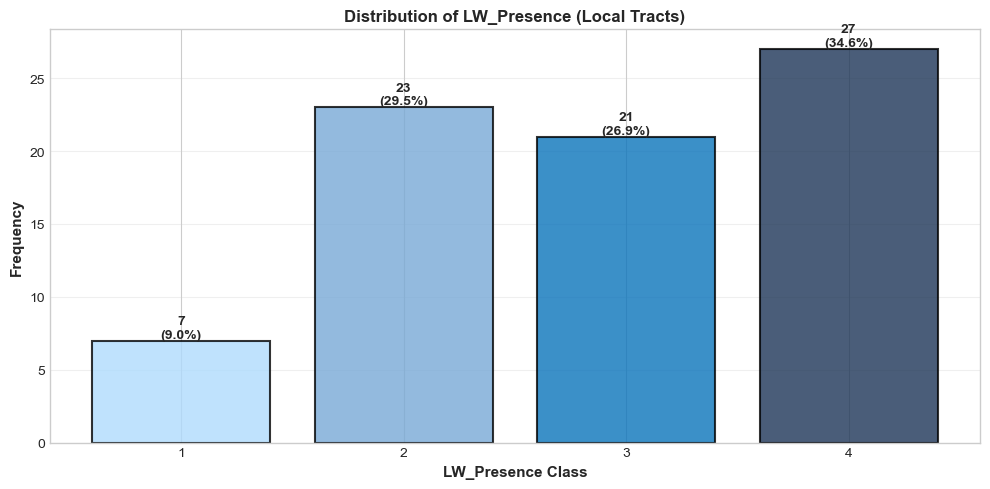


2. PREDICTOR CORRELATION ANALYSIS

Correlation Matrix Between Predictors:
                     Sinuosity  Gradient (%)  SPI / Width  Dead_Wood  \
Sinuosity                1.000        -0.002        0.026      0.277   
Gradient (%)            -0.002         1.000        0.865      0.219   
SPI / Width              0.026         0.865        1.000      0.170   
Dead_Wood                0.277         0.219        0.170      1.000   
Standing_Dead_Trees      0.205         0.099       -0.003      0.399   
Basal_Area (m2/ha)       0.146         0.200        0.203      0.476   

                     Standing_Dead_Trees  Basal_Area (m2/ha)  
Sinuosity                          0.205               0.146  
Gradient (%)                       0.099               0.200  
SPI / Width                       -0.003               0.203  
Dead_Wood                          0.399               0.476  
Standing_Dead_Trees                1.000               0.478  
Basal_Area (m2/ha)                 0.478  

In [141]:
# =====================================================================
# ORDINAL LOGISTIC REGRESSION: LW_Presence (Local) vs Upstream (n-1) Predictors
# WITH RESULTS EXPORT TO FILES
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('='*120)
print('ORDINAL LOGISTIC REGRESSION')
print('Response: LW_Presence (Local, Ordinal 1-4)')
print('Predictors: Variables from Immediately Upstream Section (n-1)')
print('='*120)

# =====================================================================
# 1) DATA PREPARATION
# =====================================================================
print('\n' + '='*120)
print('1. DATA PREPARATION')
print('='*120)

response_var = 'LW_Presence'
predictor_vars = ['Sinuosity', 'Gradient (%)', 'SPI / Width', 'Dead_Wood', 
                  'Standing_Dead_Trees', 'Basal_Area (m2/ha)']

# Select only response and predictors
df_model = df[[response_var] + predictor_vars].copy()
initial_rows = len(df_model)
df_model = df_model.dropna()
final_rows = len(df_model)
removed_rows = initial_rows - final_rows

print(f'\nVariable selection:')
print(f'  Response: {response_var}')
print(f'  Predictors ({len(predictor_vars)}): {", ".join(predictor_vars)}')

print(f'\nDataset shape:')
print(f'  Initial rows: {initial_rows}')
print(f'  After removing NAs: {final_rows}')
print(f'  Removed: {removed_rows} ({removed_rows/initial_rows*100:.1f}%)')

# Distribution of response variable
print(f'\n' + '-'*120)
print('Distribution of LW_Presence:')
print('-'*120)

lw_dist = df_model[response_var].value_counts().sort_index()
lw_pct = (lw_dist / len(df_model) * 100).round(1)
lw_cumsum = (lw_dist.cumsum() / len(df_model) * 100).round(1)

dist_df = pd.DataFrame({
    'Class': lw_dist.index,
    'Frequency': lw_dist.values,
    'Percentage (%)': lw_pct.values,
    'Cumulative (%)': lw_cumsum.values
})
print('\n' + dist_df.to_string(index=False))

# Export response distribution
path_dist = get_output_path('OrdinalModel_LW_nminus1_response_distribution.csv')
path_dist_txt = get_output_path('OrdinalModel_LW_nminus1_response_distribution.txt')
dist_df.to_csv(path_dist, index=False)
# Also export as TXT
with open(path_dist_txt, 'w') as f:
    f.write('='*120 + '\n')
    f.write('LW_PRESENCE RESPONSE DISTRIBUTION\n')
    f.write('='*120 + '\n\n')
    f.write(dist_df.to_string(index=False))

# Simple bar plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#AFDBFD', '#78A9D6', '#0A74BB', '#1D3557']
bars = ax.bar(lw_dist.index, lw_dist.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('LW_Presence Class', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of LW_Presence (Local Tracts)', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
ax.grid(axis='y', alpha=0.3)

for bar, freq, pct in zip(bars, lw_dist.values, lw_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(freq)}\n({pct}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# 2) PREDICTOR CORRELATION MATRIX
# =====================================================================
print('\n' + '='*120)
print('2. PREDICTOR CORRELATION ANALYSIS')
print('='*120)

corr_matrix = df_model[predictor_vars].corr().round(3)
print('\nCorrelation Matrix Between Predictors:')
print(corr_matrix)

# Export correlation matrix
path_corr = get_output_path('OrdinalModel_LW_nminus1_predictor_correlation.csv')
path_corr_txt = get_output_path('OrdinalModel_LW_nminus1_predictor_correlation.txt')
corr_matrix.to_csv(path_corr)
# Also export as TXT
with open(path_corr_txt, 'w') as f:
    f.write('='*120 + '\n')
    f.write('PREDICTOR CORRELATION MATRIX\n')
    f.write('='*120 + '\n\n')
    f.write(corr_matrix.to_string())

# Detect high correlations
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f'\n⚠ High correlations detected (|r| > 0.7):')
    for var1, var2, corr in high_corr_pairs:
        print(f'  {var1} ↔ {var2}: r = {corr:.3f}')
else:
    print(f'\n✓ No high correlations (|r| > 0.7) between predictors.')

# =====================================================================
# 3) FIT ORDINAL LOGISTIC REGRESSION
# =====================================================================
print('\n' + '='*120)
print('3. ORDINAL LOGISTIC REGRESSION MODEL')
print('='*120)

from statsmodels.miscmodels.ordinal_model import OrderedModel

X = df_model[predictor_vars]
y = df_model[response_var]

print(f'\n✓ Fitting OrderedModel with distr="logit"')
print(f'  Observations: {len(y)}')
print(f'  Predictors: {len(predictor_vars)}')
print(f'  Classes: {sorted(y.unique())}')

model = OrderedModel(y, X, distr='logit')
result = model.fit(disp=False)

model_summary_text = result.summary().as_text()
print('\n' + model_summary_text)

# Export model summary
path_summary = get_output_path('OrdinalModel_LW_nminus1_summary.txt')
with open(path_summary, 'w') as f:
    f.write('='*120 + '\n')
    f.write('ORDINAL LOGISTIC REGRESSION MODEL SUMMARY\n')
    f.write('Response: LW_Presence (Local, Ordinal 1-4)\n')
    f.write('Predictors: Upstream Section (n-1) Variables\n')
    f.write('='*120 + '\n\n')
    f.write(model_summary_text)

# =====================================================================
# 4) COEFFICIENT TABLES
# =====================================================================
print('\n' + '='*120)
print('4. COEFFICIENT SUMMARY - ALL PARAMETERS')
print('='*120)

coef_all = pd.DataFrame({
    'Parameter': result.params.index,
    'Coefficient': result.params.values.round(4),
    'Std Error': result.bse.values.round(4),
    'P-value': result.pvalues.values.round(4),
    'Significant': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
                   for p in result.pvalues.values]
})
print('\n' + coef_all.to_string(index=False))
print('\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05')

# Export all coefficients
path_coef_all = get_output_path('OrdinalModel_LW_nminus1_coefficients_all.csv')
path_coef_all_txt = get_output_path('OrdinalModel_LW_nminus1_coefficients_all.txt')
coef_all.to_csv(path_coef_all, index=False)
# Also export as TXT
with open(path_coef_all_txt, 'w') as f:
    f.write('='*120 + '\n')
    f.write('ALL COEFFICIENTS (INCLUDING THRESHOLDS)\n')
    f.write('='*120 + '\n\n')
    f.write(coef_all.to_string(index=False))
    f.write('\n\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05')

# Predictors only
print('\n' + '='*120)
print('5. PREDICTOR COEFFICIENTS (Excluding Thresholds)')
print('='*120)

pred_rows = [idx for idx in result.params.index if idx in predictor_vars]
coef_pred = pd.DataFrame({
    'Predictor': pred_rows,
    'Coefficient': [result.params[idx] for idx in pred_rows],
    'Std Error': [result.bse[idx] for idx in pred_rows],
    'P-value': [result.pvalues[idx] for idx in pred_rows],
    'Significant': ['***' if result.pvalues[idx] < 0.001 else '**' if result.pvalues[idx] < 0.01 
                   else '*' if result.pvalues[idx] < 0.05 else '' 
                   for idx in pred_rows]
})
print('\n' + coef_pred.to_string(index=False))

# Export predictor coefficients
path_coef_pred = get_output_path('OrdinalModel_LW_nminus1_coefficients_predictors.csv')
path_coef_pred_txt = get_output_path('OrdinalModel_LW_nminus1_coefficients_predictors.txt')
coef_pred.to_csv(path_coef_pred, index=False)
# Also export as TXT
with open(path_coef_pred_txt, 'w') as f:
    f.write('='*120 + '\n')
    f.write('PREDICTOR COEFFICIENTS (EXCLUDING THRESHOLDS)\n')
    f.write('='*120 + '\n\n')
    f.write(coef_pred.to_string(index=False))
    f.write('\n\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05')

# =====================================================================
# 6) MODEL EVALUATION
# =====================================================================
print('\n' + '='*120)
print('6. MODEL EVALUATION')
print('='*120)

# Predictions
y_pred_proba = result.predict()
classes = np.sort(df_model[response_var].unique())
y_pred = classes[np.argmax(y_pred_proba, axis=1)]
y_true = df_model[response_var].values

# Accuracy
accuracy = (y_pred == y_true).mean()
print(f'\n✓ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred, labels=sorted(classes))
cm_df = pd.DataFrame(cm, 
                     index=[f'True {c}' for c in sorted(classes)],
                     columns=[f'Pred {c}' for c in sorted(classes)])
print('\nConfusion Matrix:')
print(cm_df)

# Export confusion matrix
path_cm = get_output_path('OrdinalModel_LW_nminus1_confusion_matrix.csv')
path_cm_txt = get_output_path('OrdinalModel_LW_nminus1_confusion_matrix.txt')
cm_df.to_csv(path_cm)
# Also export as TXT
with open(path_cm_txt, 'w') as f:
    f.write('='*120 + '\n')
    f.write('CONFUSION MATRIX\n')
    f.write('='*120 + '\n\n')
    f.write(cm_df.to_string())

# Ordinal error analysis
ordinal_errors = np.abs(y_pred - y_true)
exact_match = (ordinal_errors == 0).sum()
within_1 = (ordinal_errors <= 1).sum()
within_2 = (ordinal_errors <= 2).sum()

print(f'\n✓ Ordinal Error Analysis:')
print(f'  Exact match (error=0):     {exact_match:4d}/{len(y_true)} ({exact_match/len(y_true)*100:5.2f}%)')
print(f'  Within ±1 class:           {within_1:4d}/{len(y_true)} ({within_1/len(y_true)*100:5.2f}%)')
print(f'  Within ±2 classes:         {within_2:4d}/{len(y_true)} ({within_2/len(y_true)*100:5.2f}%)')

# Error distribution
error_dist = pd.Series(ordinal_errors).value_counts().sort_index()
print(f'\nError Distribution:')
for err, count in error_dist.items():
    print(f'  Error = {err}: {count:4d} ({count/len(y_true)*100:5.2f}%)')

# Classification report
print('\n' + classification_report(y_true, y_pred, labels=sorted(classes),
                                  target_names=[f'Class {c}' for c in sorted(classes)],
                                  zero_division=0))

# =====================================================================
# 7) INTERPRETATION & METRICS EXPORT
# =====================================================================
print('\n' + '='*120)
print('7. INTERPRETATION & SUMMARY')
print('='*120)

# Classify predictors by type
geomorphic = ['Sinuosity', 'Gradient (%)', 'SPI / Width']
riparian = ['Dead_Wood', 'Standing_Dead_Trees', 'Basal_Area (m2/ha)']

# Count significant predictors by group
geomorphic_sig = sum(1 for p in geomorphic if p in predictor_vars and result.pvalues[p] < 0.05)
riparian_sig = sum(1 for p in riparian if p in predictor_vars and result.pvalues[p] < 0.05)

# Class balance
class_min = (df_model[response_var].value_counts() / len(df_model) * 100).min()
class_max = (df_model[response_var].value_counts() / len(df_model) * 100).max()
class_ratio = class_max / class_min

interpretation_text = f"""
✓ Model Signal:
  Overall: {geomorphic_sig + riparian_sig} of {len(predictor_vars)} predictors significant at α=0.05
  Geomorphic: {geomorphic_sig} of {len(geomorphic)} significant
  Riparian: {riparian_sig} of {len(riparian)} significant
  
  The model shows {'clear signal' if geomorphic_sig + riparian_sig >= 3 else 'moderate signal' if geomorphic_sig + riparian_sig >= 1 else 'weak signal'} in upstream predictors.
  {'Geomorphic variables appear to drive predictions more than riparian variables.' if geomorphic_sig > riparian_sig else 'Riparian variables and geomorphic variables contribute similarly.' if geomorphic_sig == riparian_sig else 'Riparian variables appear to drive predictions more than geomorphic variables.'}

✓ Multicollinearity:
  {f'High correlations present (r > 0.7). Coefficient estimates should be interpreted with caution.' if high_corr_pairs else 'No high correlations detected between predictors.'}

✓ Class Balance:
  Range: {class_min:.1f}% (min) to {class_max:.1f}% (max)
  Ratio: {class_ratio:.2f}x
  {'Class imbalance may affect model fit, especially for minority classes.' if class_ratio > 3 else 'Classes are reasonably balanced.'}

✓ Ordinal Performance:
  Exact match: {exact_match/len(y_true)*100:.1f}% | Within ±1: {within_1/len(y_true)*100:.1f}% | Within ±2: {within_2/len(y_true)*100:.1f}%
  The model {'shows reasonable discrimination' if within_1/len(y_true) > 0.6 else 'shows limited discrimination'} within ±1 class.
  
✓ Interpretation Notes:
  - Positive coefficients indicate association with higher LW_Presence classes
  - Negative coefficients indicate association with lower LW_Presence classes
  - Results should be interpreted cautiously within the ordinal framework
  - Upstream conditions may influence local large wood presence through transport and deposition
"""

print(interpretation_text)

# Export metrics summary
path_metrics = get_output_path('OrdinalModel_LW_nminus1_metrics.txt')
with open(path_metrics, 'w') as f:
    f.write('='*120 + '\n')
    f.write('ORDINAL LOGISTIC REGRESSION - METRICS SUMMARY\n')
    f.write('='*120 + '\n\n')
    f.write('DATA OVERVIEW\n')
    f.write('-'*120 + '\n')
    f.write(f'Initial rows: {initial_rows}\n')
    f.write(f'Rows after NA removal: {final_rows}\n')
    f.write(f'Rows removed: {removed_rows}\n\n')
    f.write('MODEL PERFORMANCE\n')
    f.write('-'*120 + '\n')
    f.write(f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n')
    f.write(f'Exact match (error=0): {exact_match}/{len(y_true)} ({exact_match/len(y_true)*100:.2f}%)\n')
    f.write(f'Within ±1 class: {within_1}/{len(y_true)} ({within_1/len(y_true)*100:.2f}%)\n')
    f.write(f'Within ±2 classes: {within_2}/{len(y_true)} ({within_2/len(y_true)*100:.2f}%)\n\n')
    f.write('PREDICTOR SIGNIFICANCE\n')
    f.write('-'*120 + '\n')
    f.write(f'Geomorphic predictors significant: {geomorphic_sig}/{len(geomorphic)}\n')
    f.write(f'Riparian predictors significant: {riparian_sig}/{len(riparian)}\n')
    f.write(f'Total predictors significant: {geomorphic_sig + riparian_sig}/{len(predictor_vars)}\n\n')
    f.write('CLASS DISTRIBUTION\n')
    f.write('-'*120 + '\n')
    f.write(f'Min class percentage: {class_min:.2f}%\n')
    f.write(f'Max class percentage: {class_max:.2f}%\n')
    f.write(f'Imbalance ratio: {class_ratio:.2f}x\n\n')
    f.write('INTERPRETATION\n')
    f.write('-'*120 + '\n')
    f.write(interpretation_text)

print('='*120)

# =====================================================================
# FILE EXPORT SUMMARY
# =====================================================================
print('\n' + '='*120)
print('FILES EXPORTED SUMMARY')
print('='*120)

export_files = [
    ('1. Response Distribution (CSV/TXT)', path_dist, path_dist_txt),
    ('2. Predictor Correlation Matrix (CSV/TXT)', path_corr, path_corr_txt),
    ('3. Model Summary (TXT)', path_summary),
    ('4. All Coefficients (CSV/TXT)', path_coef_all, path_coef_all_txt),
    ('5. Predictor Coefficients Only (CSV/TXT)', path_coef_pred, path_coef_pred_txt),
    ('6. Confusion Matrix (CSV/TXT)', path_cm, path_cm_txt),
    ('7. Metrics Summary (TXT)', path_metrics),
]

print('\n✓ All results have been exported to:\n')
for label, *paths in export_files:
    print(f'  {label}:')
    for path in paths:
        print(f'    {path}\n')

print('='*120)

In [142]:
# ============================================================
# UPSTREAM BIVARIATE PREDICTOR RANKING WITH MIXED METHODS
# ============================================================
# Purpose:
#   Evaluate bivariate associations between immediately upstream
#   predictors and local in-channel large wood (CLW) classes.
#
# Methods:
#   - Continuous predictors: Spearman's rho + Kruskal-Wallis
#   - Ordinal predictors: Somers' D
#
# Response:
#   - LW_Presence = local in-channel large wood (CLW), ordinal 1-4
#
# Important:
#   This cell assumes that df is already the prepared upstream dataset:
#   local CLW as response, upstream variables as predictors.
# ============================================================

print('\n' + '=' * 120)
print('UPSTREAM BIVARIATE PREDICTOR RANKING WITH MIXED METHODS')
print('=' * 120)

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kruskal, somersd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. OUTPUT CONFIGURATION
# ------------------------------------------------------------

# This assumes OUTPUT_DIR already exists from your global output configuration cell.
UPSTREAM_MIXED_OUTPUT_SUBFOLDER = Path("upstream") / "With_Somers"
UPSTREAM_MIXED_OUTPUT_DIR = OUTPUT_DIR / UPSTREAM_MIXED_OUTPUT_SUBFOLDER
UPSTREAM_MIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_upstream_mixed_output_path(filename):
    """
    Generate full output path for upstream mixed-method bivariate outputs.
    """
    return UPSTREAM_MIXED_OUTPUT_DIR / filename

print('\n✓ Output directory:')
print(f'  {UPSTREAM_MIXED_OUTPUT_DIR}')


# ------------------------------------------------------------
# 2. PREDICTOR TYPES
# ------------------------------------------------------------
# Continuous predictors are evaluated with Spearman rho + Kruskal-Wallis.
# Ordinal predictors are evaluated with Somers' D.

predictor_types = {
    # Continuous upstream predictors
    'Sinuosity': 'continuous',
    'Gradient (%)': 'continuous',
    'SPI / Width': 'continuous',
    'Basal_Area (m2/ha)': 'continuous',
    'P50_Height': 'continuous',
    'Height_IQR': 'continuous',
    'StructuralIndex': 'continuous',
    'Distance to outlet (km)': 'continuous',

    # Ordinal upstream predictors
    'Dead_Wood': 'ordinal',
    'Standing_Dead_Trees': 'ordinal',
    'Regeneration': 'ordinal',
    'Invasive_Ab': 'ordinal',

    # Response, included for completeness
    'LW_Presence': 'ordinal'
}


# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

def calculate_epsilon_squared(h_stat, n, k):
    """
    Epsilon-squared effect size for Kruskal-Wallis.
    """
    if n <= k:
        return np.nan
    return max((h_stat - k + 1) / (n - k), 0)


def format_p_value(p):
    """
    Format p-values using two decimals, with p < 0.01 threshold.
    """
    if pd.isna(p):
        return "NA"
    elif p < 0.01:
        return "< 0.01"
    else:
        return f"{p:.2f}"


def safe_spearman(x, y):
    """
    Compute Spearman correlation safely.
    """
    if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
        return np.nan, np.nan

    try:
        rho, p = spearmanr(x, y)
        return rho, p
    except Exception:
        return np.nan, np.nan


def safe_kruskal_by_response(x, y):
    """
    Compute Kruskal-Wallis test for predictor values grouped by ordinal response classes.
    Used only for continuous predictors.
    """
    unique_y = np.unique(y)
    groups = [x[y == val] for val in unique_y]

    if len(groups) < 2:
        return np.nan, np.nan, np.nan

    try:
        h_stat, p_kw = kruskal(*groups)
        eps_sq = calculate_epsilon_squared(h_stat, len(y), len(unique_y))
        return h_stat, p_kw, eps_sq
    except Exception:
        return np.nan, np.nan, np.nan


def safe_somersd(predictor, response):
    """
    Compute Somers' D safely.
    Predictor is treated as the explanatory ordinal variable.
    Response is treated as the dependent ordinal variable.
    """
    if len(np.unique(predictor)) < 2 or len(np.unique(response)) < 2:
        return np.nan, np.nan

    try:
        sd = somersd(predictor, response)
        return sd.statistic, sd.pvalue
    except Exception:
        return np.nan, np.nan


def classify_evidence(main_p, abs_stat):
    """
    Descriptive evidence classification using the appropriate main statistic.
    """
    if pd.isna(main_p) or pd.isna(abs_stat):
        return 'not_assessed'
    elif main_p < 0.05 and abs_stat >= 0.40:
        return 'strong_evidence'
    elif main_p < 0.05 and abs_stat >= 0.20:
        return 'moderate_evidence'
    elif main_p < 0.05:
        return 'weak_evidence'
    elif main_p < 0.10 or abs_stat >= 0.20:
        return 'weak_or_suggestive_evidence'
    else:
        return 'ambiguous_evidence'


def assign_visual_pattern(main_p, abs_stat):
    """
    Descriptive visual-pattern classification.
    """
    if pd.isna(main_p) or pd.isna(abs_stat):
        return 'not_assessed'
    elif main_p < 0.05 and abs_stat >= 0.40:
        return 'strong_pattern'
    elif main_p < 0.05 and abs_stat >= 0.20:
        return 'moderate_pattern'
    elif main_p < 0.10 or abs_stat >= 0.15:
        return 'weak_pattern'
    else:
        return 'no_clear_pattern'


def get_pattern_note(pattern):
    """
    Brief explanation for visual-pattern assignment.
    """
    notes = {
        'strong_pattern': 'clear monotonic or ordinal association',
        'moderate_pattern': 'visible association with overlap among classes',
        'weak_pattern': 'weak or suggestive association with substantial overlap',
        'no_clear_pattern': 'no clear monotonic or ordinal association',
        'not_assessed': 'not assessed'
    }
    return notes.get(pattern, 'mixed statistical signal')


def analyze_bivariate_predictor(data, response, predictor):
    """
    Analyze one upstream predictor against local CLW using the appropriate method.

    Continuous predictor:
        - Spearman rho
        - Kruskal-Wallis
        - Epsilon-squared

    Ordinal predictor:
        - Somers' D
    """
    pred_type = predictor_types.get(predictor, 'unknown')

    sub = data[[response, predictor]].dropna().copy()
    sub[response] = pd.to_numeric(sub[response], errors='coerce')
    sub[predictor] = pd.to_numeric(sub[predictor], errors='coerce')
    sub = sub.dropna().copy()

    if len(sub) == 0:
        raise ValueError(f"No valid observations for {predictor} vs {response}")

    y = sub[response].values
    x = sub[predictor].values
    n = len(sub)

    # Default values
    spearman_rho = np.nan
    spearman_p = np.nan
    kruskal_stat = np.nan
    kruskal_p = np.nan
    effect_size = np.nan
    somers_d = np.nan
    somers_p = np.nan

    if pred_type == 'continuous':
        spearman_rho, spearman_p = safe_spearman(x, y)
        kruskal_stat, kruskal_p, effect_size = safe_kruskal_by_response(x, y)

        main_statistic_type = "Spearman_rho"
        main_statistic = spearman_rho
        main_p_value = spearman_p

        p_for_score = kruskal_p if not pd.isna(kruskal_p) else spearman_p
        ranking_score = abs(spearman_rho) * 10 + (-np.log10(max(p_for_score, 1e-10))) * 5

    elif pred_type == 'ordinal':
        x_int = x.astype(int)
        y_int = y.astype(int)

        somers_d, somers_p = safe_somersd(x_int, y_int)

        main_statistic_type = "Somers_D"
        main_statistic = somers_d
        main_p_value = somers_p

        ranking_score = abs(somers_d) * 10 + (-np.log10(max(somers_p, 1e-10))) * 5

    else:
        # Fallback only if a predictor type was not defined.
        spearman_rho, spearman_p = safe_spearman(x, y)

        main_statistic_type = "Spearman_rho_unknown_type"
        main_statistic = spearman_rho
        main_p_value = spearman_p

        ranking_score = abs(spearman_rho) * 10 + (-np.log10(max(spearman_p, 1e-10))) * 5

    direction = (
        'positive' if main_statistic > 0.05 else
        'negative' if main_statistic < -0.05 else
        'near_zero'
    )

    abs_stat = abs(main_statistic) if not pd.isna(main_statistic) else np.nan
    visual_pattern = assign_visual_pattern(main_p_value, abs_stat)
    evidence_class = classify_evidence(main_p_value, abs_stat)

    return {
        'Predictor': predictor,
        'Predictor_role': 'Immediately upstream predictor',
        'Response': response,
        'Response_role': 'Local CLW response',
        'Predictor_type': pred_type,

        'Main_statistic_type': main_statistic_type,
        'Main_statistic': main_statistic,
        'Main_p_value': main_p_value,
        'Main_p_value_formatted': format_p_value(main_p_value),
        'Direction': direction,

        # Continuous-specific outputs
        'Spearman_rho': spearman_rho,
        'Spearman_p': spearman_p,
        'Spearman_p_formatted': format_p_value(spearman_p),
        'Kruskal_stat': kruskal_stat,
        'Kruskal_p': kruskal_p,
        'Kruskal_p_formatted': format_p_value(kruskal_p),
        'Effect_size_epsilon_squared': effect_size,

        # Ordinal-specific outputs
        'Somers_D': somers_d,
        'Somers_p': somers_p,
        'Somers_p_formatted': format_p_value(somers_p),

        # Descriptive interpretation
        'Visual_pattern': visual_pattern,
        'Visual_pattern_note': get_pattern_note(visual_pattern),
        'Evidence_class': evidence_class,
        'Ranking_score': ranking_score,

        # Data information
        'N': n,
        'N_unique_predictor_values': len(np.unique(x)),
        'N_response_classes': len(np.unique(y))
    }


def run_upstream_bivariate_ranking(data, response, predictors, model_label):
    """
    Run upstream bivariate ranking for local CLW response.
    """
    print('\n' + '=' * 120)
    print(f'{model_label}')
    print('=' * 120)

    predictors_avail = [p for p in predictors if p in data.columns]
    predictors_missing = [p for p in predictors if p not in data.columns]

    print(f'\n✓ Response: {response} = local CLW')
    print(f'✓ Available upstream predictors: {len(predictors_avail)}')
    print(f'  {", ".join(predictors_avail)}')

    if predictors_missing:
        print(f'\n⚠ Missing predictors and skipped:')
        print(f'  {", ".join(predictors_missing)}')

    results = []

    for pred in predictors_avail:
        result = analyze_bivariate_predictor(
            data=data,
            response=response,
            predictor=pred
        )
        results.append(result)

    df_rank = (
        pd.DataFrame(results)
        .sort_values('Ranking_score', ascending=False)
        .reset_index(drop=True)
    )

    df_rank['Ranking_position'] = range(1, len(df_rank) + 1)

    col_order = [
        'Ranking_position',
        'Predictor',
        'Predictor_role',
        'Response',
        'Response_role',
        'Predictor_type',
        'Main_statistic_type',
        'Main_statistic',
        'Main_p_value',
        'Main_p_value_formatted',
        'Direction',

        'Spearman_rho',
        'Spearman_p',
        'Spearman_p_formatted',
        'Kruskal_stat',
        'Kruskal_p',
        'Kruskal_p_formatted',
        'Effect_size_epsilon_squared',

        'Somers_D',
        'Somers_p',
        'Somers_p_formatted',

        'Visual_pattern',
        'Visual_pattern_note',
        'Evidence_class',
        'Ranking_score',
        'N',
        'N_unique_predictor_values',
        'N_response_classes'
    ]

    # Export full results
    csv_path = get_upstream_mixed_output_path('PASO3_Upstream_Ranking_LW_Presence_With_Somers.csv')
    txt_path = get_upstream_mixed_output_path('PASO3_Upstream_Ranking_LW_Presence_With_Somers.txt')

    df_rank[col_order].to_csv(csv_path, index=False)

    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write('=' * 150 + '\n')
        f.write('UPSTREAM PREDICTORS / LOCAL CLW MODEL: BIVARIATE PREDICTOR RANKING WITH MIXED METHODS\n')
        f.write('=' * 150 + '\n\n')
        f.write('Methodological note:\n')
        f.write('- The response is local in-channel large wood (CLW), stored as LW_Presence.\n')
        f.write('- Predictors are immediately upstream reach variables from the prepared upstream dataset.\n')
        f.write('- Continuous upstream predictors were evaluated using Spearman rank correlation and Kruskal-Wallis tests.\n')
        f.write('- Ordinal upstream predictors were evaluated using Somers\' D, with the upstream predictor treated as explanatory and local CLW as dependent.\n')
        f.write('- Ranking scores are descriptive and are not formal inferential statistics.\n\n')
        f.write(df_rank[col_order].to_string(index=False))

    # Export compact table for manuscript
    compact = df_rank.copy()
    compact['Bivariate_statistic_for_table'] = compact.apply(
        lambda row: (
            f"ρ = {row['Main_statistic']:.2f}"
            if row['Main_statistic_type'] == 'Spearman_rho'
            else f"Somers' D = {row['Main_statistic']:.2f}"
        ),
        axis=1
    )

    compact_table = compact[
        [
            'Predictor',
            'Predictor_type',
            'Bivariate_statistic_for_table',
            'Main_p_value_formatted',
            'N',
            'Evidence_class'
        ]
    ].copy()

    compact_path = get_upstream_mixed_output_path('PASO3_Upstream_Bivariate_Table_For_Manuscript_With_Somers.csv')
    compact_table.to_csv(compact_path, index=False)

    print(f'\n✓ Ranking summary:')
    print(
        df_rank[
            [
                'Ranking_position',
                'Predictor',
                'Predictor_type',
                'Main_statistic_type',
                'Main_statistic',
                'Main_p_value_formatted',
                'Evidence_class',
                'N'
            ]
        ].to_string(index=False)
    )

    print(f'\n✓ Exported outputs:')
    print(f'  Full CSV:       {csv_path}')
    print(f'  Full TXT:       {txt_path}')
    print(f'  Compact table:  {compact_path}')

    return df_rank, compact_table


# ------------------------------------------------------------
# 4. RUN ANALYSIS
# ------------------------------------------------------------

# Local CLW response in the prepared upstream dataset
lw_response = 'LW_Presence'

# Immediately upstream predictors
# Keep only those you want to evaluate in the upstream analysis.
upstream_predictors = [
    'Sinuosity',
    'Gradient (%)',
    'SPI / Width',
    'Dead_Wood',
    'Standing_Dead_Trees',
    'Basal_Area (m2/ha)'
]

df_rank_upstream_lw, df_upstream_bivariate_table = run_upstream_bivariate_ranking(
    data=df,
    response=lw_response,
    predictors=upstream_predictors,
    model_label='UPSTREAM PREDICTORS / LOCAL CLW MODEL'
)


# ------------------------------------------------------------
# 5. METHOD SUMMARY
# ------------------------------------------------------------

summary_path = get_upstream_mixed_output_path('PASO3_Upstream_With_Somers_Method_Summary.txt')

with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('=' * 120 + '\n')
    f.write('UPSTREAM BIVARIATE ANALYSIS WITH MIXED METHODS\n')
    f.write('=' * 120 + '\n\n')
    f.write('Response:\n')
    f.write('- LW_Presence: local in-channel large wood (CLW), ordinal 1-4.\n\n')
    f.write('Predictors:\n')
    f.write('- Predictors are immediately upstream reach variables from the prepared upstream dataset.\n\n')
    f.write('Methods:\n')
    f.write('- Continuous predictors: Spearman rank correlation and Kruskal-Wallis tests.\n')
    f.write('- Ordinal predictors: Somers\' D, with the upstream predictor treated as explanatory and local CLW as dependent.\n\n')
    f.write('Predictor classification:\n')
    for pred in upstream_predictors:
        f.write(f'- {pred}: {predictor_types.get(pred, "unknown")}\n')
    f.write('\nOutputs:\n')
    f.write('- PASO3_Upstream_Ranking_LW_Presence_With_Somers.csv\n')
    f.write('- PASO3_Upstream_Ranking_LW_Presence_With_Somers.txt\n')
    f.write('- PASO3_Upstream_Bivariate_Table_For_Manuscript_With_Somers.csv\n')

print('\n' + '=' * 120)
print('UPSTREAM BIVARIATE ANALYSIS COMPLETED')
print('=' * 120)
print(f'Output folder: {UPSTREAM_MIXED_OUTPUT_DIR}')
print(f'Method summary: {summary_path}')

print('\n✓ Compact manuscript table preview:')
print(df_upstream_bivariate_table.to_string(index=False))


UPSTREAM BIVARIATE PREDICTOR RANKING WITH MIXED METHODS

✓ Output directory:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1_UPSTREEAM2_(VariablesSubBasin\upstream\With_Somers

UPSTREAM PREDICTORS / LOCAL CLW MODEL

✓ Response: LW_Presence = local CLW
✓ Available upstream predictors: 6
  Sinuosity, Gradient (%), SPI / Width, Dead_Wood, Standing_Dead_Trees, Basal_Area (m2/ha)

✓ Ranking summary:
 Ranking_position           Predictor Predictor_type Main_statistic_type  Main_statistic Main_p_value_formatted     Evidence_class  N
                1  Basal_Area (m2/ha)     continuous        Spearman_rho       -0.167473                   0.14 ambiguous_evidence 78
                2 Standing_Dead_Trees        ordinal            Somers_D        0.147818                   0.12 ambiguous_evidence 78
                3           Sinuosity     continuous        Spearman_rho       -0.079412                   0.49 ambiguous_evidence 78
        

In [143]:
# =====================================================================
# UPSTREAM ORDINAL LOGISTIC REGRESSION + GLOBAL TABLE SUMMARY
# =====================================================================
# Purpose:
#   Fit the multivariable ordinal logistic regression model relating
#   local CLW classes to immediately upstream predictors, then combine
#   these multivariable results with the corrected bivariate upstream
#   results from the previous cell.
#
# Inputs required:
#   - df: prepared upstream dataset
#       Response: LW_Presence = local CLW
#       Predictors: immediately upstream reach variables
#
#   - Existing bivariate file from previous cell:
#       PASO3_Upstream_Bivariate_Table_For_Manuscript_With_Somers.csv
#
# Outputs:
#   1. PASO4_Upstream_Ordinal_Model_For_Manuscript.csv
#   2. PASO4_Upstream_Ordinal_Model_For_Manuscript.txt
#   3. Table2_Upstream_Bivariate_Multivariable_Global_Summary.csv
#   4. Table2_Upstream_Bivariate_Multivariable_Global_Summary.txt
#   5. Table2_Upstream_Verification_Report.txt
#
# Important:
#   - The ordinal model can include continuous and ordinal predictors.
#   - Ordinal predictors are entered as ordered numeric scores.
#   - Model coefficients are conditional associations.
# =====================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings
warnings.filterwarnings("ignore")

print("\n" + "=" * 120)
print("UPSTREAM ORDINAL MODEL + GLOBAL TABLE SUMMARY")
print("=" * 120)

# =====================================================================
# 0) OUTPUT CONFIGURATION
# =====================================================================

UPSTREAM_MIXED_OUTPUT_SUBFOLDER = Path("upstream") / "With_Somers"
UPSTREAM_MIXED_OUTPUT_DIR = OUTPUT_DIR / UPSTREAM_MIXED_OUTPUT_SUBFOLDER
UPSTREAM_MIXED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_upstream_mixed_output_path(filename):
    """
    Generate full output path for updated upstream outputs.
    """
    return UPSTREAM_MIXED_OUTPUT_DIR / filename

print("\n✓ Output directory:")
print(f"  {UPSTREAM_MIXED_OUTPUT_DIR}")


# =====================================================================
# 1) MODEL SETTINGS
# =====================================================================

response_var = "LW_Presence"  # local CLW response, ordinal 1-4

predictor_vars = [
    "Sinuosity",
    "Gradient (%)",
    "SPI / Width",
    "Dead_Wood",
    "Standing_Dead_Trees",
    "Basal_Area (m2/ha)"
]

predictor_display_names = {
    "Sinuosity": "Sinuosity",
    "Gradient (%)": "Gradient (%)",
    "SPI / Width": "SPI / Width",
    "Dead_Wood": "Upstream FLW",
    "Standing_Dead_Trees": "Standing dead trees",
    "Basal_Area (m2/ha)": "Basal area (m²/ha)"
}

predictor_types = {
    "Sinuosity": "continuous",
    "Gradient (%)": "continuous",
    "SPI / Width": "continuous",
    "Dead_Wood": "ordinal",
    "Standing_Dead_Trees": "ordinal",
    "Basal_Area (m2/ha)": "continuous"
}

print("\n✓ Model definition:")
print(f"  Response: {response_var} = local CLW")
print(f"  Predictors: {', '.join(predictor_vars)}")


# =====================================================================
# 2) DATA PREPARATION
# =====================================================================

required_cols = [response_var] + predictor_vars
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise KeyError(
        "The following required columns are missing from df:\n"
        f"{missing_cols}\n\n"
        f"Available columns:\n{list(df.columns)}"
    )

df_model = df[required_cols].copy()
initial_n = len(df_model)

for col in required_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.dropna(subset=required_cols).copy()
final_n = len(df_model)
removed_n = initial_n - final_n

df_model[response_var] = df_model[response_var].astype(int)

print("\n✓ Data preparation:")
print(f"  Initial N: {initial_n}")
print(f"  Final N after NA removal: {final_n}")
print(f"  Removed N: {removed_n}")

response_distribution = (
    df_model[response_var]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Frequency")
)

response_distribution["Percentage"] = (
    response_distribution["Frequency"] / final_n * 100
).round(2)

print("\n✓ Response distribution:")
print(response_distribution.to_string(index=False))


# =====================================================================
# 3) PREDICTOR REDUNDANCY CHECK
# =====================================================================

# Diagnostic only. Spearman is used because predictors include both
# continuous and ordered ordinal variables.
predictor_spearman_corr = df_model[predictor_vars].corr(method="spearman").round(3)

high_corr_pairs = []
for i in range(len(predictor_spearman_corr.columns)):
    for j in range(i + 1, len(predictor_spearman_corr.columns)):
        corr_value = predictor_spearman_corr.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append(
                (
                    predictor_spearman_corr.columns[i],
                    predictor_spearman_corr.columns[j],
                    corr_value
                )
            )

print("\n✓ Predictor redundancy diagnostic:")
if high_corr_pairs:
    print("  High Spearman correlations detected (|rho| > 0.7):")
    for var1, var2, corr_value in high_corr_pairs:
        print(f"    {var1} ↔ {var2}: rho = {corr_value:.3f}")
else:
    print("  No high Spearman correlations detected (|rho| > 0.7).")


# =====================================================================
# 4) FIT ORDINAL LOGISTIC REGRESSION
# =====================================================================

X = df_model[predictor_vars]
y = df_model[response_var]

print("\n✓ Fitting OrderedModel with logit link:")
print(f"  Observations: {len(y)}")
print(f"  Predictors: {len(predictor_vars)}")
print(f"  Response classes: {sorted(y.unique())}")

model = OrderedModel(y, X, distr="logit")
result = model.fit(disp=False)

model_summary_text = result.summary().as_text()

print("\n✓ Model fitted.")
print(f"  Log-likelihood: {result.llf:.2f}")
print(f"  AIC: {result.aic:.2f}")
print(f"  BIC: {result.bic:.2f}")


# =====================================================================
# 5) MODEL COEFFICIENT TABLE FOR MANUSCRIPT
# =====================================================================

def format_p_value(p):
    """
    Format p-values using two decimals, with p < 0.01 threshold.
    """
    if pd.isna(p):
        return "NA"
    elif p < 0.01:
        return "< 0.01"
    else:
        return f"{p:.2f}"

def significance_code(p):
    """
    Significance code for manuscript-style table.
    """
    if pd.isna(p):
        return ""
    elif p < 0.05:
        return "*"
    else:
        return ""

pred_rows = [idx for idx in result.params.index if idx in predictor_vars]

model_table = pd.DataFrame({
    "Predictor": pred_rows,
    "Predictor_display": [predictor_display_names.get(p, p) for p in pred_rows],
    "Predictor_type": [predictor_types.get(p, "unknown") for p in pred_rows],
    "Multivariable_coefficient": [result.params[p] for p in pred_rows],
    "Std_error": [result.bse[p] for p in pred_rows],
    "Multivariable_p_raw": [result.pvalues[p] for p in pred_rows]
})

model_table["Multivariable_coefficient_rounded"] = model_table["Multivariable_coefficient"].round(2)
model_table["Std_error_rounded"] = model_table["Std_error"].round(2)
model_table["Multivariable_p_value"] = model_table["Multivariable_p_raw"].apply(format_p_value)
model_table["Multivariable_significant"] = model_table["Multivariable_p_raw"].apply(significance_code)

model_table_for_export = model_table[
    [
        "Predictor",
        "Predictor_display",
        "Predictor_type",
        "Multivariable_coefficient_rounded",
        "Std_error_rounded",
        "Multivariable_p_value",
        "Multivariable_significant"
    ]
].copy()

path_model_csv = get_upstream_mixed_output_path(
    "PASO4_Upstream_Ordinal_Model_For_Manuscript.csv"
)
path_model_txt = get_upstream_mixed_output_path(
    "PASO4_Upstream_Ordinal_Model_For_Manuscript.txt"
)

model_table_for_export.to_csv(path_model_csv, index=False)

with open(path_model_txt, "w", encoding="utf-8") as f:
    f.write("=" * 120 + "\n")
    f.write("UPSTREAM ORDINAL LOGISTIC REGRESSION MODEL FOR MANUSCRIPT\n")
    f.write("=" * 120 + "\n\n")
    f.write("Response:\n")
    f.write("- LW_Presence = local in-channel large wood (CLW), ordinal classes 1-4.\n\n")
    f.write("Predictors:\n")
    f.write("- Immediately upstream reach variables.\n\n")
    f.write("Interpretation:\n")
    f.write("- Coefficients are conditional associations with higher local CLW classes.\n")
    f.write("- Ordinal predictors are entered as ordered numeric scores.\n")
    f.write("- Positive coefficients indicate association with higher local CLW classes.\n")
    f.write("- Negative coefficients indicate association with lower local CLW classes.\n\n")
    f.write("Model summary:\n")
    f.write(f"- Final N: {final_n}\n")
    f.write(f"- Log-likelihood: {result.llf:.2f}\n")
    f.write(f"- AIC: {result.aic:.2f}\n")
    f.write(f"- BIC: {result.bic:.2f}\n\n")
    f.write("Predictor coefficients:\n")
    f.write("-" * 120 + "\n")
    f.write(model_table_for_export.to_string(index=False))
    f.write("\n\n")
    f.write("Full statsmodels summary:\n")
    f.write("-" * 120 + "\n")
    f.write(model_summary_text)

print("\n✓ Multivariable model table exported:")
print(f"  CSV: {path_model_csv}")
print(f"  TXT: {path_model_txt}")


# =====================================================================
# 6) APPARENT MODEL FIT METRICS
# =====================================================================

y_pred_proba = result.predict()
classes = np.sort(df_model[response_var].unique())
y_pred = classes[np.argmax(y_pred_proba, axis=1)]
y_true = df_model[response_var].values

ordinal_errors = np.abs(y_pred - y_true)

exact_match_accuracy = (ordinal_errors == 0).mean()
within_1_accuracy = (ordinal_errors <= 1).mean()
within_2_accuracy = (ordinal_errors <= 2).mean()

fit_metrics = {
    "Exact_match_accuracy": round(exact_match_accuracy, 3),
    "Within_1_class_accuracy": round(within_1_accuracy, 3),
    "Within_2_class_accuracy": round(within_2_accuracy, 3),
    "AIC": round(result.aic, 2),
    "BIC": round(result.bic, 2),
    "Log_likelihood": round(result.llf, 2)
}

print("\n✓ Apparent model fit:")
print(f"  Exact match accuracy: {fit_metrics['Exact_match_accuracy']}")
print(f"  Within ±1 class accuracy: {fit_metrics['Within_1_class_accuracy']}")
print(f"  Within ±2 class accuracy: {fit_metrics['Within_2_class_accuracy']}")


# =====================================================================
# 7) READ PREVIOUS BIVARIATE TABLE
# =====================================================================

path_bivariate_csv = get_upstream_mixed_output_path(
    "PASO3_Upstream_Bivariate_Table_For_Manuscript_With_Somers.csv"
)

if not path_bivariate_csv.exists():
    raise FileNotFoundError(
        "The corrected bivariate table was not found.\n"
        f"Expected file:\n{path_bivariate_csv}\n\n"
        "Run the previous upstream bivariate cell first."
    )

biv_table = pd.read_csv(path_bivariate_csv)

print("\n✓ Corrected bivariate table loaded:")
print(f"  {path_bivariate_csv}")
print(f"  Rows: {len(biv_table)}")
print(f"  Columns: {list(biv_table.columns)}")


# =====================================================================
# 8) STANDARDIZE BIVARIATE TABLE COLUMNS
# =====================================================================

# Expected columns from previous cell:
#   Predictor
#   Predictor_type
#   Bivariate_statistic_for_table
#   Main_p_value_formatted
#   N
#   Evidence_class

required_biv_cols = [
    "Predictor",
    "Predictor_type",
    "Bivariate_statistic_for_table",
    "Main_p_value_formatted",
    "N"
]

missing_biv_cols = [col for col in required_biv_cols if col not in biv_table.columns]

if missing_biv_cols:
    raise KeyError(
        "The bivariate table does not contain the expected columns:\n"
        f"{missing_biv_cols}\n\n"
        f"Available columns:\n{list(biv_table.columns)}"
    )

biv_for_merge = biv_table.copy()

biv_for_merge = biv_for_merge.rename(columns={
    "Bivariate_statistic_for_table": "Bivariate_statistic",
    "Main_p_value_formatted": "Bivariate_p_value",
    "N": "Bivariate_N"
})

biv_for_merge["Predictor_display"] = biv_for_merge["Predictor"].map(
    predictor_display_names
).fillna(biv_for_merge["Predictor"])

biv_for_merge = biv_for_merge[
    [
        "Predictor",
        "Predictor_display",
        "Predictor_type",
        "Bivariate_statistic",
        "Bivariate_p_value",
        "Bivariate_N"
    ]
].copy()


# =====================================================================
# 9) CREATE GLOBAL SUMMARY TABLE
# =====================================================================

global_summary = biv_for_merge.merge(
    model_table_for_export[
        [
            "Predictor",
            "Multivariable_coefficient_rounded",
            "Std_error_rounded",
            "Multivariable_p_value",
            "Multivariable_significant"
        ]
    ],
    on="Predictor",
    how="left"
)

# Preserve desired order
order_df = pd.DataFrame({
    "Predictor": predictor_vars,
    "Order": range(1, len(predictor_vars) + 1)
})

global_summary = global_summary.merge(order_df, on="Predictor", how="left")
global_summary = global_summary.sort_values("Order").drop(columns=["Order"])

# Rename for final manuscript readability
global_summary = global_summary.rename(columns={
    "Predictor_display": "Upstream_variable",
    "Predictor_type": "Variable_type",
    "Bivariate_N": "N",
    "Multivariable_coefficient_rounded": "Coef",
    "Std_error_rounded": "SE",
    "Multivariable_p_value": "Multivariable_p_value",
    "Multivariable_significant": "Significant"
})

global_summary = global_summary[
    [
        "Upstream_variable",
        "Variable_type",
        "Bivariate_statistic",
        "Bivariate_p_value",
        "Coef",
        "SE",
        "Multivariable_p_value",
        "Significant",
        "N"
    ]
].copy()

path_global_csv = get_upstream_mixed_output_path(
    "Table2_Upstream_Bivariate_Multivariable_Global_Summary.csv"
)
path_global_txt = get_upstream_mixed_output_path(
    "Table2_Upstream_Bivariate_Multivariable_Global_Summary.txt"
)

global_summary.to_csv(path_global_csv, index=False)

with open(path_global_txt, "w", encoding="utf-8") as f:
    f.write("=" * 120 + "\n")
    f.write("TABLE 2 GLOBAL SUMMARY: UPSTREAM BIVARIATE + MULTIVARIABLE ANALYSIS\n")
    f.write("=" * 120 + "\n\n")
    f.write("Response:\n")
    f.write("- Local in-channel large wood (CLW), stored as LW_Presence, ordinal classes 1-4.\n\n")
    f.write("Bivariate analysis:\n")
    f.write("- Continuous upstream predictors: Spearman's rho.\n")
    f.write("- Ordinal upstream predictors: Somers' D.\n")
    f.write("- For Somers' D, the upstream variable was treated as explanatory and local CLW as dependent.\n\n")
    f.write("Multivariable analysis:\n")
    f.write("- Cumulative ordinal logistic regression with logit link.\n")
    f.write("- Coefficients indicate conditional associations with higher local CLW classes.\n")
    f.write("- Ordinal predictors were entered as ordered numeric scores.\n\n")
    f.write("Model information:\n")
    f.write(f"- Final N used in multivariable model: {final_n}\n")
    f.write(f"- AIC: {result.aic:.2f}\n")
    f.write(f"- BIC: {result.bic:.2f}\n")
    f.write(f"- Exact match accuracy: {exact_match_accuracy:.3f}\n")
    f.write(f"- Accuracy within ±1 class: {within_1_accuracy:.3f}\n")
    f.write(f"- Accuracy within ±2 classes: {within_2_accuracy:.3f}\n\n")
    f.write("Global summary table:\n")
    f.write("-" * 120 + "\n")
    f.write(global_summary.to_string(index=False))

print("\n✓ Global summary table exported:")
print(f"  CSV: {path_global_csv}")
print(f"  TXT: {path_global_txt}")


# =====================================================================
# 10) VERIFICATION REPORT
# =====================================================================

path_verification_txt = get_upstream_mixed_output_path(
    "Table2_Upstream_Verification_Report.txt"
)

biv_predictors = set(biv_for_merge["Predictor"])
model_predictors = set(model_table_for_export["Predictor"])

missing_in_bivariate = [p for p in predictor_vars if p not in biv_predictors]
missing_in_model = [p for p in predictor_vars if p not in model_predictors]

with open(path_verification_txt, "w", encoding="utf-8") as f:
    f.write("=" * 120 + "\n")
    f.write("VERIFICATION REPORT: UPSTREAM TABLE 2 INPUTS AND MODEL\n")
    f.write("=" * 120 + "\n\n")

    f.write("Files used:\n")
    f.write(f"- Bivariate input CSV: {path_bivariate_csv}\n")
    f.write(f"- Multivariable output CSV: {path_model_csv}\n")
    f.write(f"- Global summary CSV: {path_global_csv}\n\n")

    f.write("Dataset:\n")
    f.write(f"- Initial N: {initial_n}\n")
    f.write(f"- Final N after NA removal for model: {final_n}\n")
    f.write(f"- Removed N: {removed_n}\n\n")

    f.write("Response distribution used in multivariable model:\n")
    f.write(response_distribution.to_string(index=False))
    f.write("\n\n")

    f.write("Predictor list:\n")
    for p in predictor_vars:
        f.write(f"- {p}: {predictor_types.get(p, 'unknown')}\n")
    f.write("\n")

    f.write("Predictor redundancy diagnostic:\n")
    if high_corr_pairs:
        f.write("- High Spearman correlations detected (|rho| > 0.7):\n")
        for var1, var2, corr_value in high_corr_pairs:
            f.write(f"  {var1} ↔ {var2}: rho = {corr_value:.3f}\n")
    else:
        f.write("- No high Spearman correlations detected (|rho| > 0.7).\n")
    f.write("\n")

    f.write("Merge checks:\n")
    f.write(f"- Predictors missing in bivariate table: {missing_in_bivariate if missing_in_bivariate else 'None'}\n")
    f.write(f"- Predictors missing in multivariable model: {missing_in_model if missing_in_model else 'None'}\n\n")

    f.write("Model fit:\n")
    f.write(f"- Log-likelihood: {result.llf:.2f}\n")
    f.write(f"- AIC: {result.aic:.2f}\n")
    f.write(f"- BIC: {result.bic:.2f}\n")
    f.write(f"- Exact match accuracy: {exact_match_accuracy:.3f}\n")
    f.write(f"- Accuracy within ±1 class: {within_1_accuracy:.3f}\n")
    f.write(f"- Accuracy within ±2 classes: {within_2_accuracy:.3f}\n\n")

    f.write("Global summary preview:\n")
    f.write("-" * 120 + "\n")
    f.write(global_summary.to_string(index=False))

print("\n✓ Verification report exported:")
print(f"  TXT: {path_verification_txt}")


# =====================================================================
# 11) FINAL PRINT SUMMARY
# =====================================================================

print("\n" + "=" * 120)
print("EXPORTS COMPLETED")
print("=" * 120)

print("\nEssential outputs:")
print(f"1. Global summary CSV:")
print(f"   {path_global_csv}")
print(f"2. Global summary TXT:")
print(f"   {path_global_txt}")
print(f"3. Verification TXT:")
print(f"   {path_verification_txt}")

print("\nSupporting model outputs:")
print(f"4. Multivariable model CSV:")
print(f"   {path_model_csv}")
print(f"5. Multivariable model TXT:")
print(f"   {path_model_txt}")

print("\nPreview of final global summary:")
print(global_summary.to_string(index=False))

print("\n" + "=" * 120)
print("DONE")
print("=" * 120)


UPSTREAM ORDINAL MODEL + GLOBAL TABLE SUMMARY



✓ Output directory:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1_UPSTREEAM2_(VariablesSubBasin\upstream\With_Somers

✓ Model definition:
  Response: LW_Presence = local CLW
  Predictors: Sinuosity, Gradient (%), SPI / Width, Dead_Wood, Standing_Dead_Trees, Basal_Area (m2/ha)

✓ Data preparation:
  Initial N: 78
  Final N after NA removal: 78
  Removed N: 0

✓ Response distribution:
 Class  Frequency  Percentage
     1          7        8.97
     2         23       29.49
     3         21       26.92
     4         27       34.62

✓ Predictor redundancy diagnostic:
  High Spearman correlations detected (|rho| > 0.7):
    Gradient (%) ↔ SPI / Width: rho = 0.947

✓ Fitting OrderedModel with logit link:
  Observations: 78
  Predictors: 6
  Response classes: [1, 2, 3, 4]

✓ Model fitted.
  Log-likelihood: -94.29
  AIC: 206.57
  BIC: 227.78

✓ Multivariable model table exported:
  CSV: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV